**PART A — MATPLOTLIB MASTERY — 8 PROFESSIONAL CHART TYPES
(STEPS 1–6)**

**Step 1**

In [1]:
# ============================================
# STEP 1 — ENVIRONMENT SETUP & DATA LOADING
# ============================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)

# Ignore warnings for cleaner notebook
import warnings
warnings.filterwarnings('ignore')


# -----------------------------
# 2. PROFESSIONAL PLOT SETTINGS
# -----------------------------

plt.style.use('seaborn-v0_8-whitegrid')

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#f8f9fa'

plt.rcParams['axes.edgecolor'] = '#333333'
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 16

plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

plt.rcParams['grid.alpha'] = 0.3
plt.rcParams['grid.linestyle'] = '--'

plt.rcParams['legend.fontsize'] = 10


# Seaborn Theme
sns.set_theme(style="whitegrid", palette="deep")


# -----------------------------
# 3. LOAD DATASET
# -----------------------------

df = pd.read_csv('train.csv')

print("="*60)
print("DATASET LOADED SUCCESSFULLY")
print("="*60)


# -----------------------------
# 4. BASIC DATASET INFORMATION
# -----------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])


# -----------------------------
# 5. DATASET INFO
# -----------------------------

print("\n" + "="*60)
print("DATASET INFO")
print("="*60)

print(df.info())


# -----------------------------
# 6. DESCRIPTIVE STATISTICS
# -----------------------------

print("\n" + "="*60)
print("NUMERICAL SUMMARY")
print("="*60)

print(df.describe())


# -----------------------------
# 7. IDENTIFY COLUMN TYPES
# -----------------------------

numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

categorical_cols = df.select_dtypes(include=['object']).columns


print("\n" + "="*60)
print("COLUMN TYPE ANALYSIS")
print("="*60)

print(f"\nNumber of Numerical Columns: {len(numerical_cols)}")
print(f"Number of Categorical Columns: {len(categorical_cols)}")


print("\nFirst 10 Numerical Columns:")
print(list(numerical_cols[:10]))

print("\nFirst 10 Categorical Columns:")
print(list(categorical_cols[:10]))


# -----------------------------
# 8. CORRELATION WITH TARGET
# -----------------------------

print("\n" + "="*60)
print("TOP 10 FEATURES CORRELATED WITH SALEPRICE")
print("="*60)

correlation_with_target = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(10)
)

print(correlation_with_target)


# -----------------------------
# 9. OPTIONAL - VISUAL PREVIEW
# -----------------------------

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)

display(df.head())

DATASET LOADED SUCCESSFULLY

Dataset Shape:
(1460, 81)

Rows: 1460
Columns: 81

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  Hou

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
import os
os.makedirs("figures", exist_ok=True)

**Step 2**

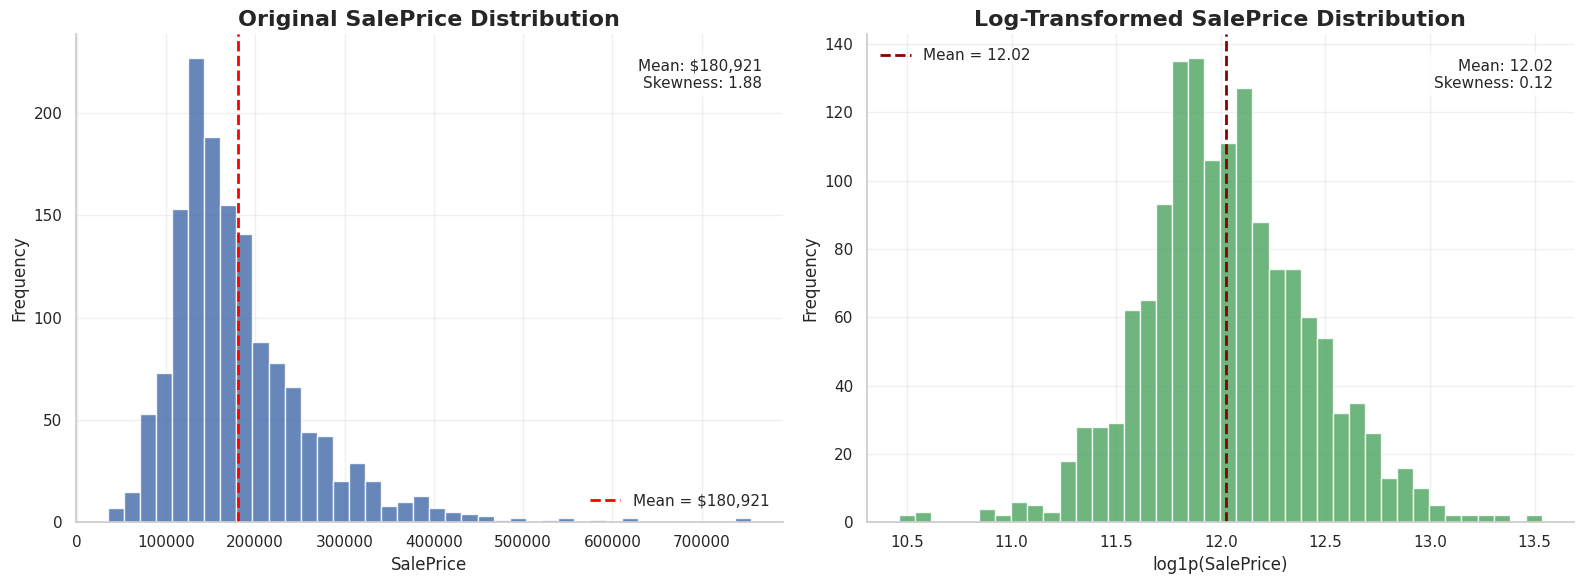

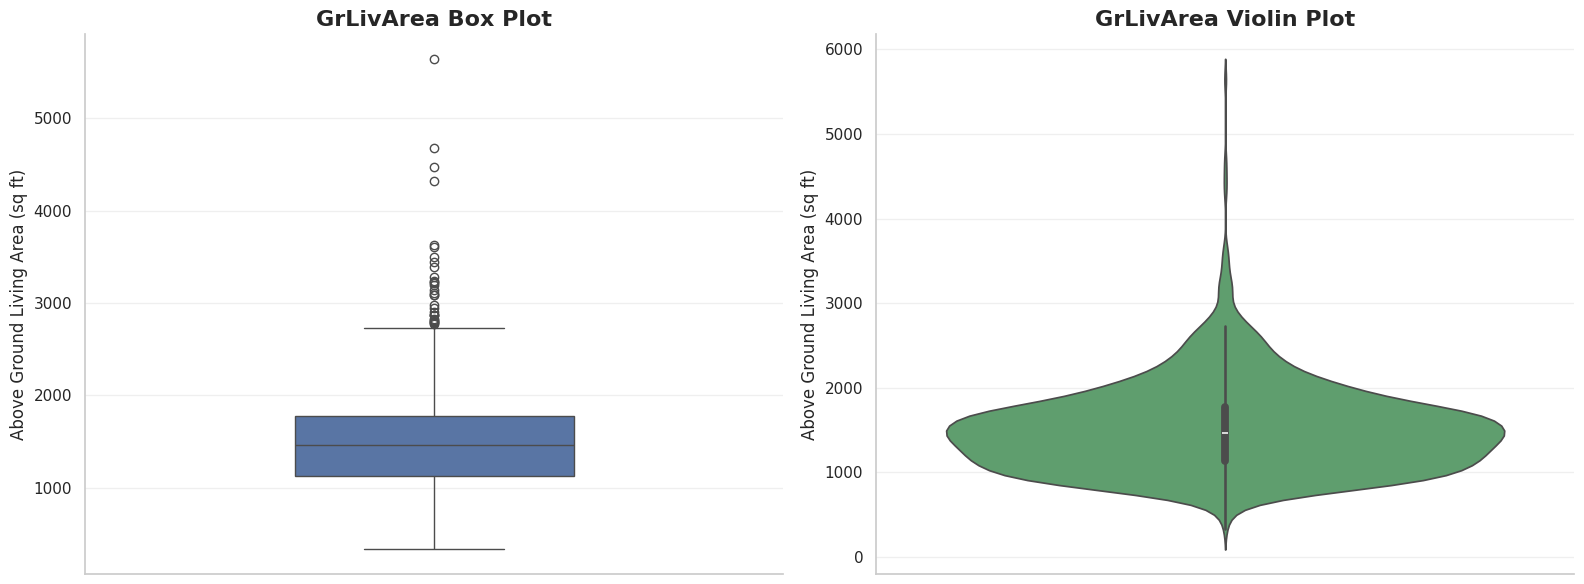

SALEPRICE DISTRIBUTION STATISTICS
Original SalePrice Skewness : 1.88
Log-Transformed Skewness    : 0.12

Interpretation:
Log transformation successfully reduced skewness.


In [3]:
# =========================================================
# STEP 2 — DISTRIBUTION ANALYSIS
# =========================================================

# ---------------------------------------------------------
# CHART 1 — SALEPRICE DISTRIBUTION
# ---------------------------------------------------------

# Calculate statistics
saleprice_mean = df['SalePrice'].mean()
saleprice_skew = df['SalePrice'].skew()

log_saleprice = np.log1p(df['SalePrice'])
log_mean = log_saleprice.mean()
log_skew = log_saleprice.skew()


# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# LEFT PLOT — ORIGINAL SALEPRICE
# ---------------------------------------------------------

axes[0].hist(
    df['SalePrice'],
    bins=40,
    color='#4C72B0',
    edgecolor='white',
    alpha=0.85
)

# Mean line
axes[0].axvline(
    saleprice_mean,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean = ${saleprice_mean:,.0f}'
)

# Titles and labels
axes[0].set_title(
    'Original SalePrice Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

# Annotation
axes[0].text(
    0.97,
    0.95,
    f'Mean: ${saleprice_mean:,.0f}\nSkewness: {saleprice_skew:.2f}',
    transform=axes[0].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

axes[0].legend()

# Clean spines
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ---------------------------------------------------------
# RIGHT PLOT — LOG TRANSFORMED SALEPRICE
# ---------------------------------------------------------

axes[1].hist(
    log_saleprice,
    bins=40,
    color='#55A868',
    edgecolor='white',
    alpha=0.85
)

# Mean line
axes[1].axvline(
    log_mean,
    color='darkred',
    linestyle='--',
    linewidth=2,
    label=f'Mean = {log_mean:.2f}'
)

# Titles and labels
axes[1].set_title(
    'Log-Transformed SalePrice Distribution',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_xlabel('log1p(SalePrice)')
axes[1].set_ylabel('Frequency')

# Annotation
axes[1].text(
    0.97,
    0.95,
    f'Mean: {log_mean:.2f}\nSkewness: {log_skew:.2f}',
    transform=axes[1].transAxes,
    fontsize=11,
    verticalalignment='top',
    horizontalalignment='right',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)

axes[1].legend()

# Clean spines
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    'figures/w3_saleprice_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# CHART 2 — GRLIVAREA DISTRIBUTION
# ---------------------------------------------------------

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ---------------------------------------------------------
# LEFT PLOT — BOXPLOT
# ---------------------------------------------------------

sns.boxplot(
    y=df['GrLivArea'],
    ax=axes[0],
    color='#4C72B0',
    width=0.4
)

axes[0].set_title(
    'GrLivArea Box Plot',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Above Ground Living Area (sq ft)')
axes[0].set_xlabel('')

# Clean spines
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# ---------------------------------------------------------
# RIGHT PLOT — VIOLIN PLOT
# ---------------------------------------------------------

sns.violinplot(
    y=df['GrLivArea'],
    ax=axes[1],
    color='#55A868'
)

axes[1].set_title(
    'GrLivArea Violin Plot',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_ylabel('Above Ground Living Area (sq ft)')
axes[1].set_xlabel('')

# Clean spines
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    'figures/w3_grlivarea_distribution.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# PRINT SUMMARY STATISTICS
# ---------------------------------------------------------

print("="*60)
print("SALEPRICE DISTRIBUTION STATISTICS")
print("="*60)

print(f"Original SalePrice Skewness : {saleprice_skew:.2f}")
print(f"Log-Transformed Skewness    : {log_skew:.2f}")

print("\nInterpretation:")
if abs(log_skew) < abs(saleprice_skew):
    print("Log transformation successfully reduced skewness.")
else:
    print("Log transformation did not improve skewness.")

**Step 3**

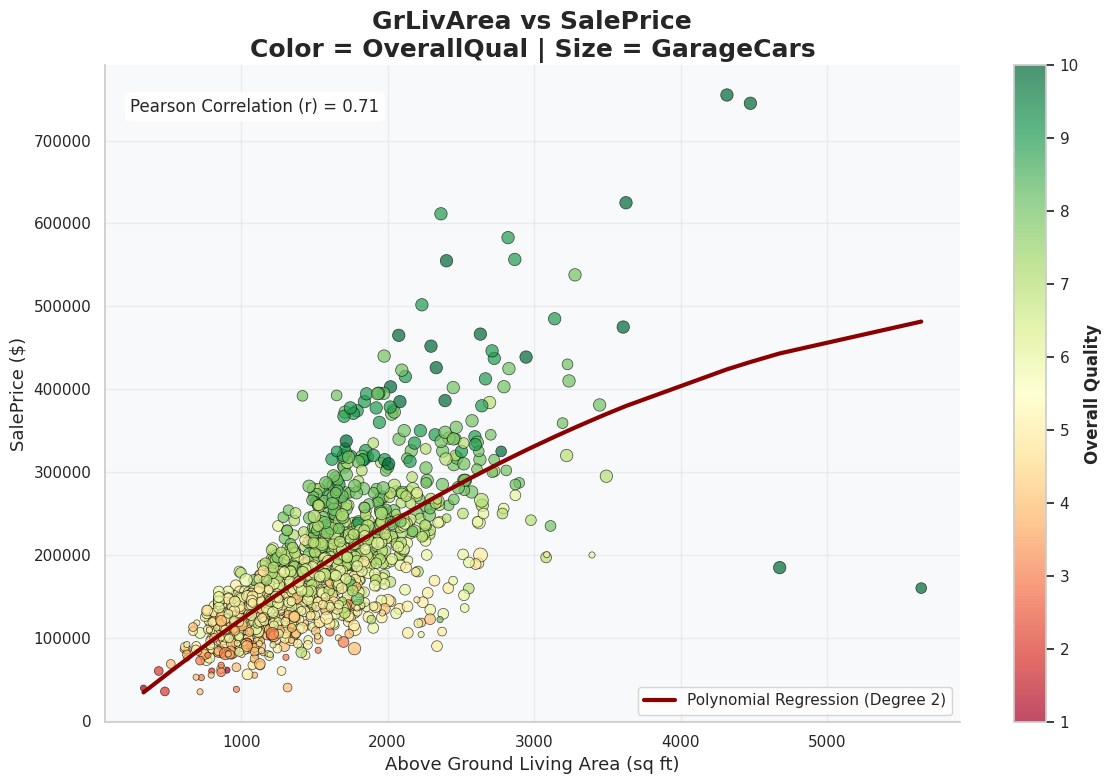

MULTI-VARIABLE SCATTER PLOT ANALYSIS
Pearson Correlation between GrLivArea and SalePrice: 0.709

Encoded Variables:
1. X-axis       -> GrLivArea
2. Y-axis       -> SalePrice
3. Color        -> OverallQual
4. Point Size   -> GarageCars

Interpretation:
Larger homes generally have higher sale prices.
Higher quality homes (green/yellow colors) tend to sell at higher prices.
Homes with larger garages appear as larger points.
The polynomial regression line captures the non-linear relationship.


In [4]:
# =========================================================
# STEP 3 — MULTI-VARIABLE SCATTER PLOT
# =========================================================

# ---------------------------------------------------------
# PREPARE VARIABLES
# ---------------------------------------------------------

x = df['GrLivArea']
y = df['SalePrice']

# Color encoding
colors = df['OverallQual']

# Size encoding
sizes = df['GarageCars'] * 20 + 20


# ---------------------------------------------------------
# CALCULATE CORRELATION
# ---------------------------------------------------------

pearson_corr = df['GrLivArea'].corr(df['SalePrice'])


# ---------------------------------------------------------
# CREATE FIGURE
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

ax = plt.gca()


# ---------------------------------------------------------
# SCATTER PLOT
# ---------------------------------------------------------

scatter = plt.scatter(
    x,
    y,
    c=colors,
    s=sizes,
    cmap=plt.cm.RdYlGn,
    alpha=0.7,
    edgecolors='black',
    linewidths=0.5
)


# ---------------------------------------------------------
# COLORBAR
# ---------------------------------------------------------

cbar = plt.colorbar(scatter)

cbar.set_label(
    'Overall Quality',
    fontsize=12,
    fontweight='bold'
)


# ---------------------------------------------------------
# POLYNOMIAL REGRESSION LINE (DEGREE = 2)
# ---------------------------------------------------------

# Fit polynomial
z = np.polyfit(x, y, 2)

# Create polynomial function
p = np.poly1d(z)

# Sort values for smooth curve
x_sorted = np.sort(x)

# Plot regression curve
plt.plot(
    x_sorted,
    p(x_sorted),
    color='darkred',
    linewidth=3,
    label='Polynomial Regression (Degree 2)'
)


# ---------------------------------------------------------
# CORRELATION ANNOTATION
# ---------------------------------------------------------

plt.text(
    0.03,
    0.95,
    f'Pearson Correlation (r) = {pearson_corr:.2f}',
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment='top',
    bbox=dict(
        boxstyle='round',
        facecolor='white',
        alpha=0.9
    )
)


# ---------------------------------------------------------
# TITLES & LABELS
# ---------------------------------------------------------

plt.title(
    'GrLivArea vs SalePrice\n'
    'Color = OverallQual | Size = GarageCars',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Above Ground Living Area (sq ft)',
    fontsize=13
)

plt.ylabel(
    'SalePrice ($)',
    fontsize=13
)


# ---------------------------------------------------------
# LEGEND
# ---------------------------------------------------------

plt.legend(
    loc='lower right',
    frameon=True
)


# ---------------------------------------------------------
# STYLE CLEANUP
# ---------------------------------------------------------

ax.set_facecolor('#f8f9fa')

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.tight_layout()

plt.savefig(
    'figures/w3_multivariable_scatter.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# PRINT INTERPRETATION
# ---------------------------------------------------------

print("="*60)
print("MULTI-VARIABLE SCATTER PLOT ANALYSIS")
print("="*60)

print(f"Pearson Correlation between GrLivArea and SalePrice: {pearson_corr:.3f}")

print("\nEncoded Variables:")
print("1. X-axis       -> GrLivArea")
print("2. Y-axis       -> SalePrice")
print("3. Color        -> OverallQual")
print("4. Point Size   -> GarageCars")

print("\nInterpretation:")
print("Larger homes generally have higher sale prices.")
print("Higher quality homes (green/yellow colors) tend to sell at higher prices.")
print("Homes with larger garages appear as larger points.")
print("The polynomial regression line captures the non-linear relationship.")

**Step 4**

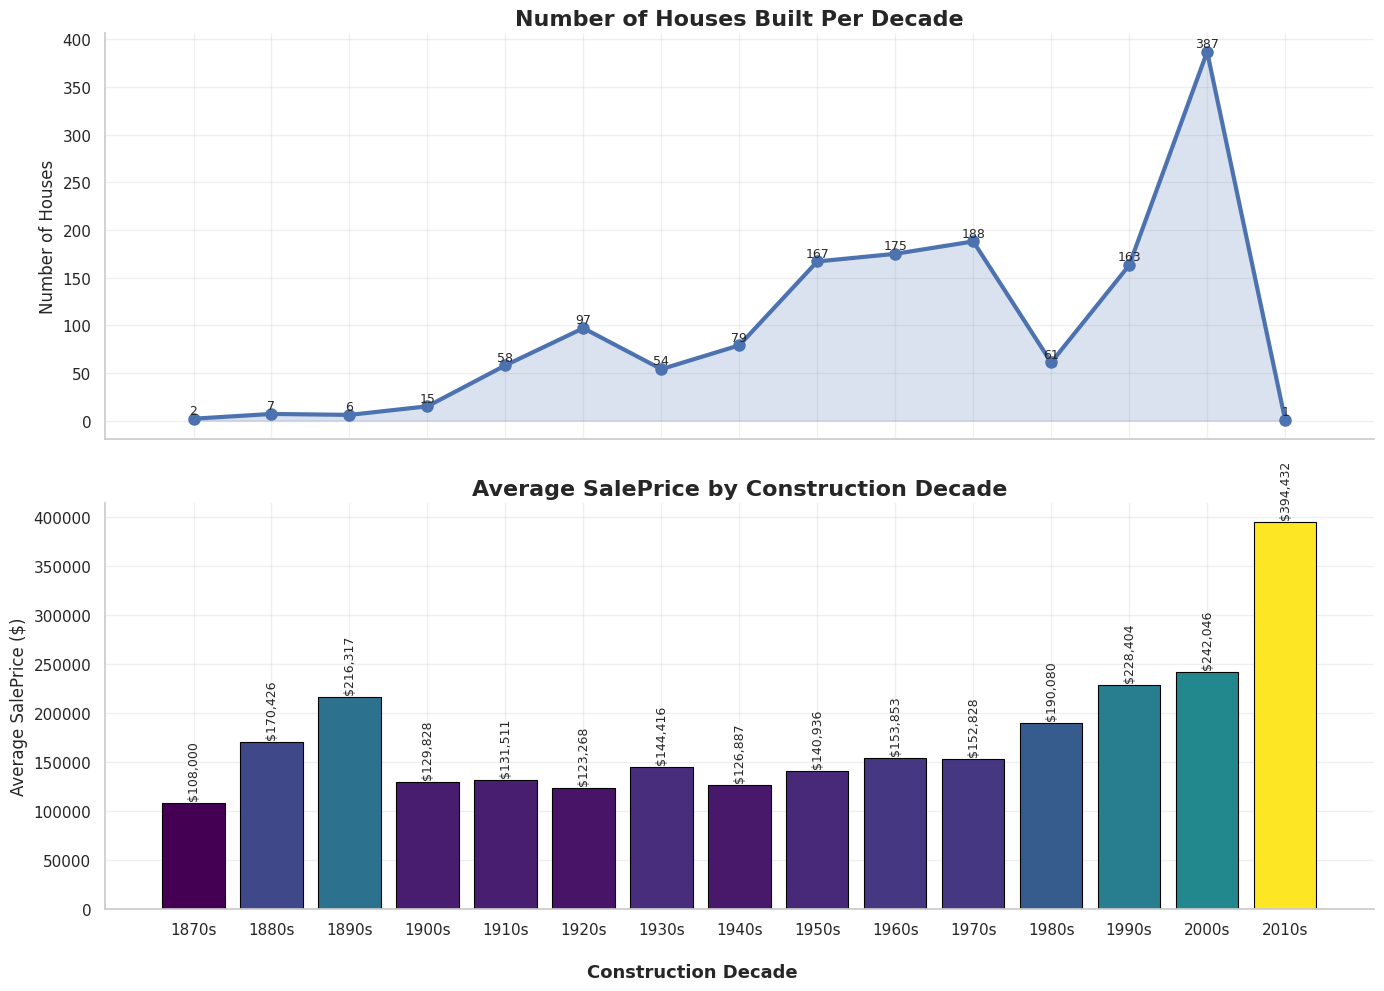

TIME-BASED TREND ANALYSIS
Most Houses Built In: 2000s
Count of Houses: 387

Highest Average SalePrice Decade: 2010s
Average Price: $394,432

Interpretation:
Newer homes generally have higher average sale prices.
Construction activity increased significantly in later decades.
Modern homes tend to command premium prices.


In [5]:
# =========================================================
# STEP 4 — TIME-BASED TREND ANALYSIS
# =========================================================

# ---------------------------------------------------------
# CREATE DECADE COLUMN
# ---------------------------------------------------------

df['DecadeBuilt'] = (df['YearBuilt'] // 10) * 10

# Convert to readable labels
df['DecadeLabel'] = df['DecadeBuilt'].astype(str) + 's'


# ---------------------------------------------------------
# AGGREGATE DATA
# ---------------------------------------------------------

# Count of houses by decade
decade_counts = (
    df.groupby('DecadeLabel')
    .size()
)

# Average SalePrice by decade
avg_price_by_decade = (
    df.groupby('DecadeLabel')['SalePrice']
    .mean()
)

# Ensure correct chronological order
decades_sorted = sorted(df['DecadeBuilt'].unique())

decade_labels_sorted = [f"{d}s" for d in decades_sorted]

decade_counts = decade_counts.reindex(decade_labels_sorted)
avg_price_by_decade = avg_price_by_decade.reindex(decade_labels_sorted)


# ---------------------------------------------------------
# CREATE FIGURE
# ---------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10),
    sharex=True
)


# =========================================================
# TOP SUBPLOT — HOUSE COUNT BY DECADE
# =========================================================

axes[0].plot(
    decade_labels_sorted,
    decade_counts.values,
    marker='o',
    linewidth=3,
    markersize=8,
    color='#4C72B0'
)

axes[0].fill_between(
    decade_labels_sorted,
    decade_counts.values,
    alpha=0.2,
    color='#4C72B0'
)

axes[0].set_title(
    'Number of Houses Built Per Decade',
    fontsize=16,
    fontweight='bold'
)

axes[0].set_ylabel('Number of Houses')

axes[0].grid(alpha=0.3)

# Annotate values
for i, value in enumerate(decade_counts.values):
    axes[0].text(
        i,
        value + 5,
        str(value),
        ha='center',
        fontsize=9
    )

# Clean spines
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)


# =========================================================
# BOTTOM SUBPLOT — AVERAGE SALEPRICE BY DECADE
# =========================================================

# Normalize values for colormap
norm = plt.Normalize(
    avg_price_by_decade.min(),
    avg_price_by_decade.max()
)

colors = plt.cm.viridis(norm(avg_price_by_decade.values))

bars = axes[1].bar(
    decade_labels_sorted,
    avg_price_by_decade.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8
)

axes[1].set_title(
    'Average SalePrice by Construction Decade',
    fontsize=16,
    fontweight='bold'
)

axes[1].set_ylabel('Average SalePrice ($)')

axes[1].grid(alpha=0.3)

# Add value labels on bars
for bar in bars:

    height = bar.get_height()

    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        height + 3000,
        f'${height:,.0f}',
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=90
    )

# Clean spines
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


# =========================================================
# SHARED X-AXIS LABEL
# =========================================================

fig.supxlabel(
    'Construction Decade',
    fontsize=13,
    fontweight='bold'
)


# ---------------------------------------------------------
# LAYOUT ADJUSTMENT
# ---------------------------------------------------------

plt.subplots_adjust(hspace=0.35)

plt.tight_layout()


# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.savefig(
    'figures/w3_time_trend.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# PRINT SUMMARY
# ---------------------------------------------------------

highest_price_decade = avg_price_by_decade.idxmax()
highest_price_value = avg_price_by_decade.max()

most_common_decade = decade_counts.idxmax()
most_common_count = decade_counts.max()

print("="*60)
print("TIME-BASED TREND ANALYSIS")
print("="*60)

print(f"Most Houses Built In: {most_common_decade}")
print(f"Count of Houses: {most_common_count}")

print(f"\nHighest Average SalePrice Decade: {highest_price_decade}")
print(f"Average Price: ${highest_price_value:,.0f}")

print("\nInterpretation:")
print("Newer homes generally have higher average sale prices.")
print("Construction activity increased significantly in later decades.")
print("Modern homes tend to command premium prices.")

**Step 5**

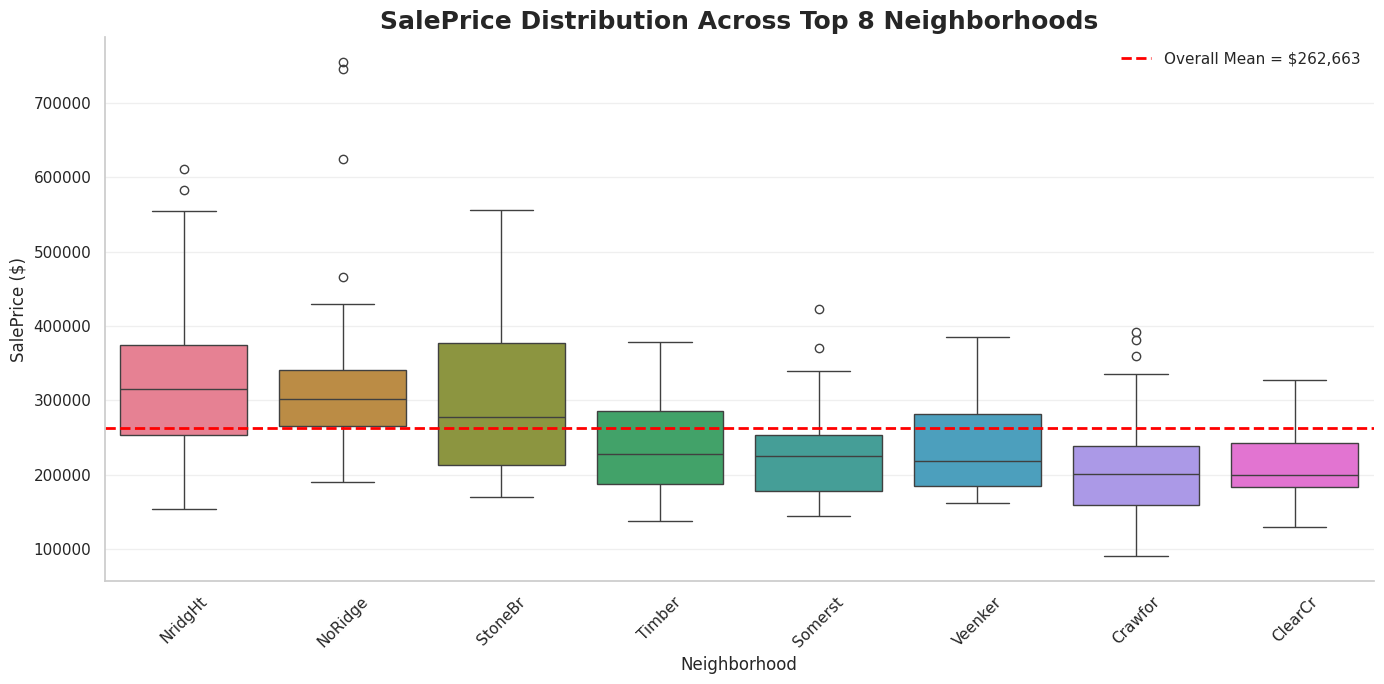

TOP 8 NEIGHBORHOODS BY MEDIAN SALEPRICE
Neighborhood
NridgHt    315000.0
NoRidge    301500.0
StoneBr    278000.0
Timber     228475.0
Somerst    225500.0
Veenker    218000.0
Crawfor    200624.0
ClearCr    200250.0
Name: SalePrice, dtype: float64


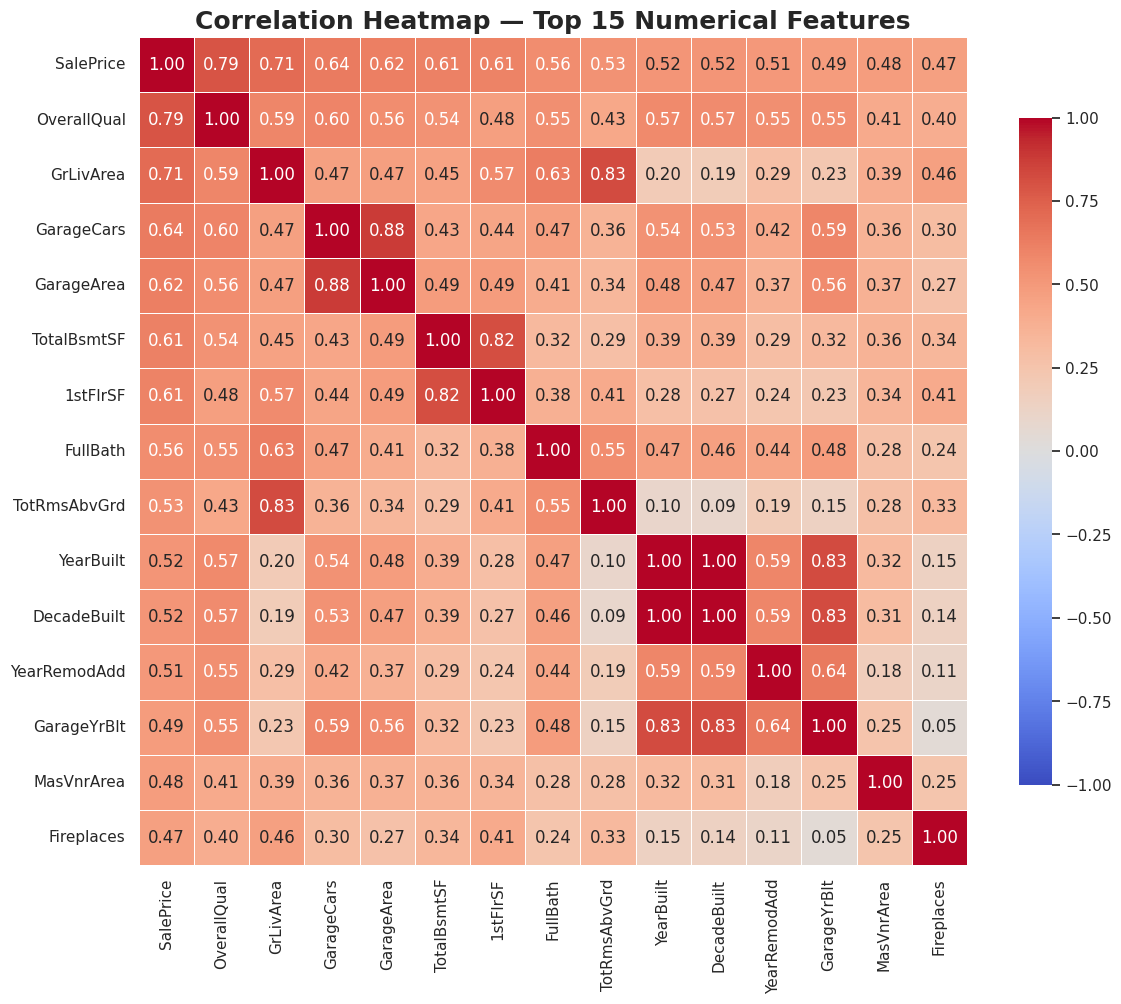


HEATMAP ANALYSIS

Top Features Correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
DecadeBuilt     0.515824
Name: SalePrice, dtype: float64

Interpretation:
OverallQual and GrLivArea remain among the strongest predictors.
Several garage-related features show strong correlation.
The heatmap also reveals multicollinearity between some variables.


In [6]:
# =========================================================
# STEP 5 — SEABORN STATISTICAL VISUALIZATION
# =========================================================

# ---------------------------------------------------------
# CHART 5 — SALEPRICE BY TOP 8 NEIGHBORHOODS
# ---------------------------------------------------------

# Find top 8 neighborhoods by median SalePrice
top_neighborhoods = (
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .head(8)
    .index
)

# Filter dataset
filtered_df = df[df['Neighborhood'].isin(top_neighborhoods)]

# Create figure
plt.figure(figsize=(14, 7))

# Create boxplot
ax = sns.boxplot(
    data=filtered_df,
    x='Neighborhood',
    y='SalePrice',
    order=top_neighborhoods,
    palette='husl'
)

# ---------------------------------------------------------
# ADD MEAN LINE
# ---------------------------------------------------------

overall_mean = filtered_df['SalePrice'].mean()

ax.axhline(
    overall_mean,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Overall Mean = ${overall_mean:,.0f}'
)

# ---------------------------------------------------------
# TITLES & LABELS
# ---------------------------------------------------------

plt.title(
    'SalePrice Distribution Across Top 8 Neighborhoods',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel(
    'Neighborhood',
    fontsize=12
)

plt.ylabel(
    'SalePrice ($)',
    fontsize=12
)

# Rotate x labels
plt.xticks(rotation=45)

# Legend
plt.legend()

# Clean spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    'figures/w3_neighborhood_boxplot.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# PRINT NEIGHBORHOOD SUMMARY
# ---------------------------------------------------------

print("="*60)
print("TOP 8 NEIGHBORHOODS BY MEDIAN SALEPRICE")
print("="*60)

print(
    df.groupby('Neighborhood')['SalePrice']
    .median()
    .sort_values(ascending=False)
    .head(8)
)


# =========================================================
# CHART 6 — CORRELATION HEATMAP
# =========================================================

# ---------------------------------------------------------
# SELECT TOP 15 NUMERICAL FEATURES
# ---------------------------------------------------------

top_features = (
    df.corr(numeric_only=True)['SalePrice']
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# Correlation matrix
corr_matrix = df[top_features].corr()


# ---------------------------------------------------------
# CREATE HEATMAP
# ---------------------------------------------------------

plt.figure(figsize=(12, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)

# ---------------------------------------------------------
# TITLES
# ---------------------------------------------------------

plt.title(
    'Correlation Heatmap — Top 15 Numerical Features',
    fontsize=18,
    fontweight='bold'
)

# Layout
plt.tight_layout()

# Save figure
plt.savefig(
    'figures/w3_correlation_heatmap.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# PRINT CORRELATION INSIGHTS
# ---------------------------------------------------------

print("\n" + "="*60)
print("HEATMAP ANALYSIS")
print("="*60)

strongest_corr = (
    corr_matrix['SalePrice']
    .drop('SalePrice')
    .sort_values(ascending=False)
)

print("\nTop Features Correlated with SalePrice:")
print(strongest_corr.head(10))

print("\nInterpretation:")
print("OverallQual and GrLivArea remain among the strongest predictors.")
print("Several garage-related features show strong correlation.")
print("The heatmap also reveals multicollinearity between some variables.")

**Step 6**

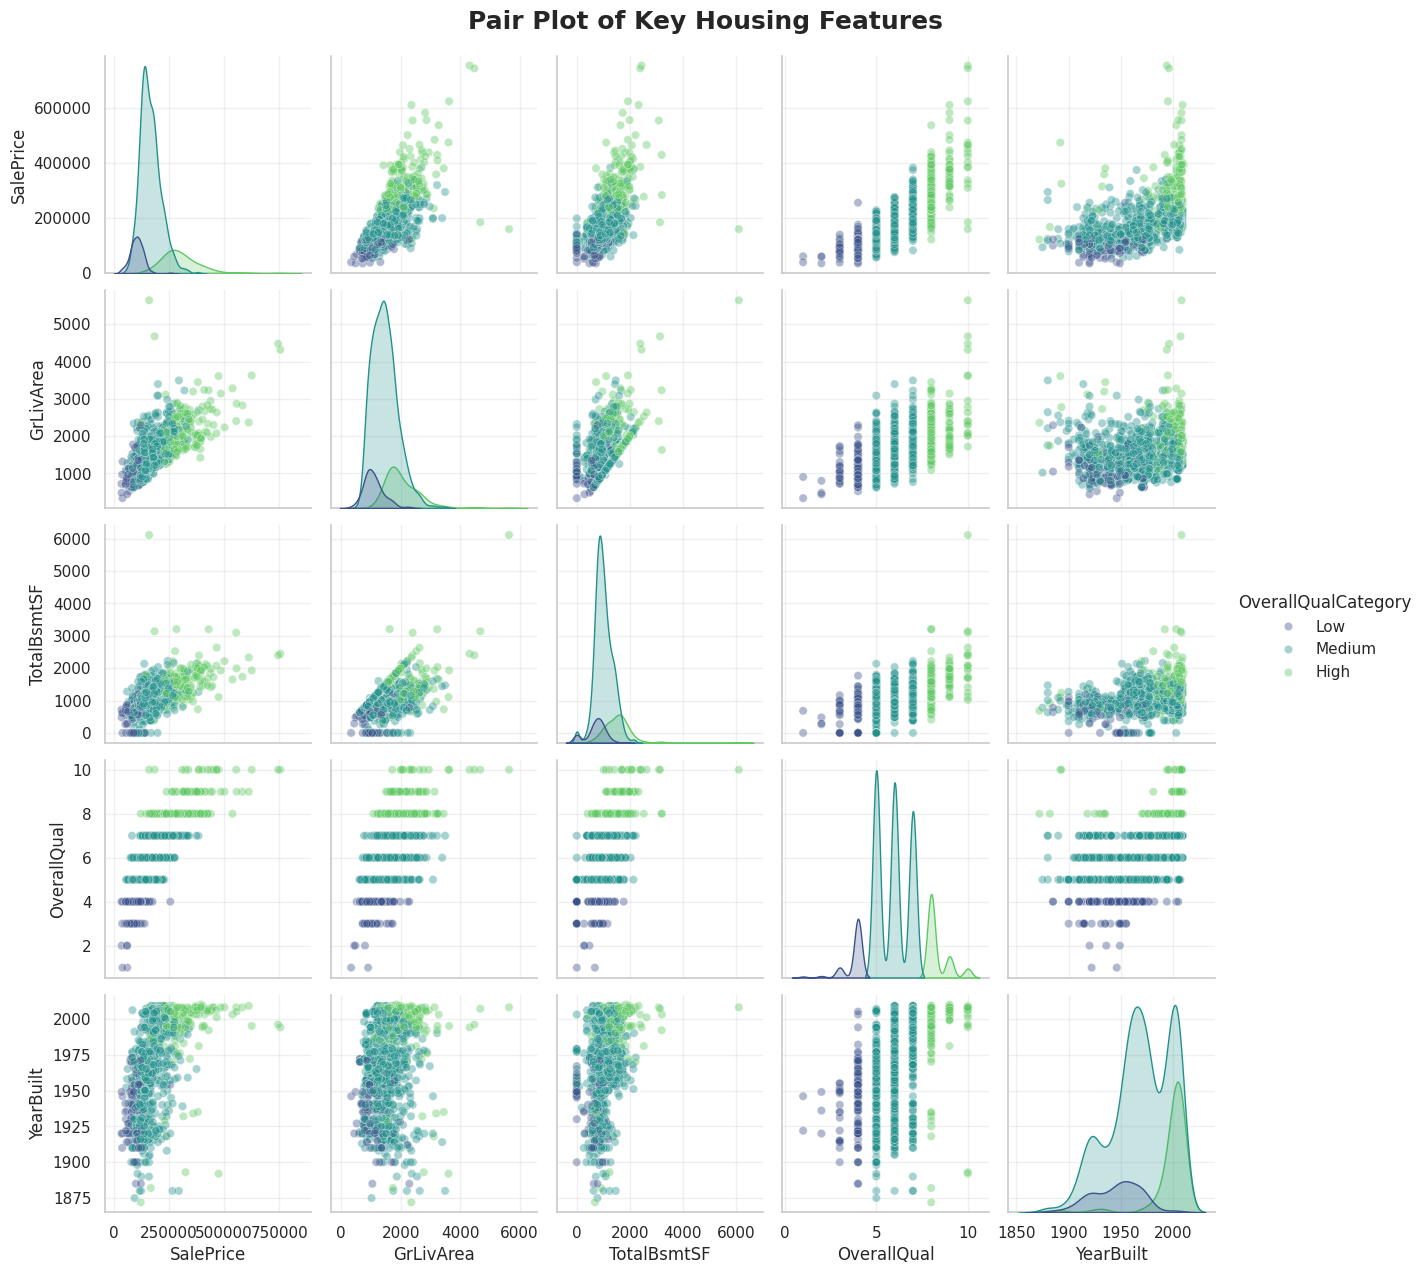

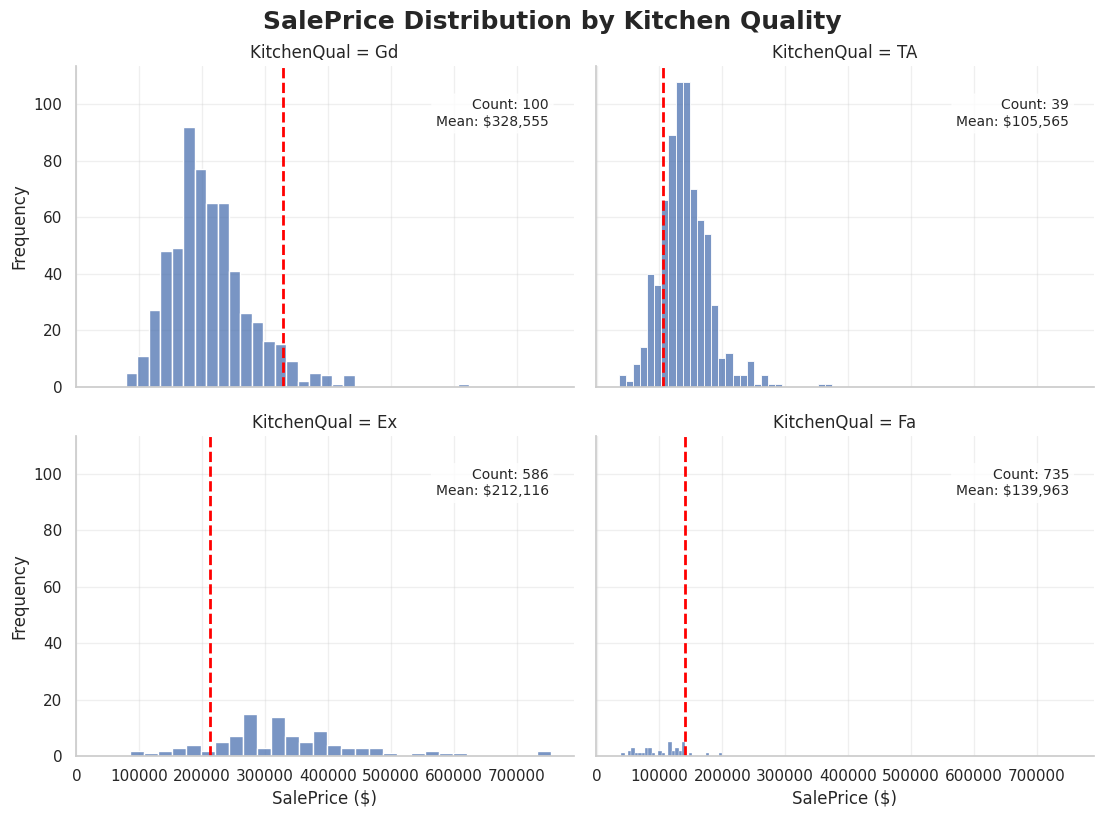

PAIRPLOT & FACETGRID ANALYSIS

Pairplot Variables:
- SalePrice
- GrLivArea
- TotalBsmtSF
- OverallQual
- YearBuilt

Kitchen Quality Categories:
KitchenQual
TA    735
Gd    586
Ex    100
Fa     39
Name: count, dtype: int64

Interpretation:
Higher OverallQual homes generally cluster at higher SalePrice values.
Kitchen quality strongly influences SalePrice distributions.
Excellent kitchen quality categories show substantially higher prices.
Several numerical variables exhibit positive linear relationships.


In [7]:
# =========================================================
# STEP 6 — ADVANCED SEABORN VISUALIZATIONS
# =========================================================

# =========================================================
# CHART 7 — PAIRPLOT
# =========================================================

# ---------------------------------------------------------
# CREATE QUALITY BINS
# ---------------------------------------------------------

df['OverallQualCategory'] = pd.cut(
    df['OverallQual'],
    bins=[0, 4, 7, 10],
    labels=['Low', 'Medium', 'High']
)

# ---------------------------------------------------------
# SELECT COLUMNS
# ---------------------------------------------------------

pairplot_cols = [
    'SalePrice',
    'GrLivArea',
    'TotalBsmtSF',
    'OverallQual',
    'YearBuilt',
    'OverallQualCategory'
]

pairplot_df = df[pairplot_cols]


# ---------------------------------------------------------
# CREATE PAIRPLOT
# ---------------------------------------------------------

pair_plot = sns.pairplot(
    pairplot_df,
    hue='OverallQualCategory',
    diag_kind='kde',
    plot_kws=dict(alpha=0.4),
    palette='viridis'
)

# ---------------------------------------------------------
# TITLE
# ---------------------------------------------------------

pair_plot.fig.suptitle(
    'Pair Plot of Key Housing Features',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

pair_plot.savefig(
    'figures/w3_pairplot.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# CHART 8 — FACETGRID
# =========================================================

# ---------------------------------------------------------
# CREATE FACETGRID
# ---------------------------------------------------------

g = sns.FacetGrid(
    df,
    col='KitchenQual',
    col_wrap=2,
    height=4,
    aspect=1.4
)

# ---------------------------------------------------------
# MAP HISTOGRAMS
# ---------------------------------------------------------

g.map_dataframe(
    sns.histplot,
    x='SalePrice',
    bins=30,
    color='#4C72B0'
)


# ---------------------------------------------------------
# ADD MEAN LINES & ANNOTATIONS
# ---------------------------------------------------------

for ax, quality in zip(g.axes.flat, sorted(df['KitchenQual'].dropna().unique())):

    subset = df[df['KitchenQual'] == quality]

    mean_price = subset['SalePrice'].mean()
    count = subset.shape[0]

    # Mean line
    ax.axvline(
        mean_price,
        color='red',
        linestyle='--',
        linewidth=2
    )

    # Annotation
    ax.text(
        0.95,
        0.90,
        f'Count: {count}\nMean: ${mean_price:,.0f}',
        transform=ax.transAxes,
        ha='right',
        va='top',
        fontsize=10,
        bbox=dict(
            boxstyle='round',
            facecolor='white',
            alpha=0.8
        )
    )


# ---------------------------------------------------------
# TITLES & LABELS
# ---------------------------------------------------------

g.fig.suptitle(
    'SalePrice Distribution by Kitchen Quality',
    fontsize=18,
    fontweight='bold',
    y=1.02
)

g.set_axis_labels(
    'SalePrice ($)',
    'Frequency'
)

# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

g.savefig(
    'figures/w3_facetgrid.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# PRINT ANALYSIS
# =========================================================

print("="*60)
print("PAIRPLOT & FACETGRID ANALYSIS")
print("="*60)

print("\nPairplot Variables:")
for col in pairplot_cols[:-1]:
    print(f"- {col}")

print("\nKitchen Quality Categories:")
print(df['KitchenQual'].value_counts())

print("\nInterpretation:")
print("Higher OverallQual homes generally cluster at higher SalePrice values.")
print("Kitchen quality strongly influences SalePrice distributions.")
print("Excellent kitchen quality categories show substantially higher prices.")
print("Several numerical variables exhibit positive linear relationships.")

**PART B — FEATURE ENGINEERING — CREATION & ENCODING (STEPS 7–
11)**

**Step 7**

In [8]:
# =========================================================
# STEP 7 — FEATURE ENGINEERING
# =========================================================

# ---------------------------------------------------------
# CREATE 8 ENGINEERED FEATURES
# ---------------------------------------------------------

# (a) TotalSF
# Combines basement and above-ground floor areas to represent total usable living space.
df['TotalSF'] = (
    df['TotalBsmtSF']
    + df['1stFlrSF']
    + df['2ndFlrSF']
)

# (b) TotalBaths
# Creates a weighted bathroom feature where half baths contribute less than full baths.
df['TotalBaths'] = (
    df['FullBath']
    + 0.5 * df['HalfBath']
    + df['BsmtFullBath']
    + 0.5 * df['BsmtHalfBath']
)

# (c) HouseAge
# Measures the age of the house at the time it was sold.
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

# (d) RemodelAge
# Measures how many years passed since the last remodel at the time of sale.
df['RemodelAge'] = df['YrSold'] - df['YearRemodAdd']

# (e) HasRemodeled
# Binary indicator showing whether the house was remodeled after construction.
df['HasRemodeled'] = (
    df['YearBuilt'] != df['YearRemodAdd']
).astype(int)

# (f) QualCond
# Interaction feature combining overall quality and overall condition into one score.
df['QualCond'] = (
    df['OverallQual']
    * df['OverallCond']
)

# (g) PricePerSF
# Represents price density by dividing sale price by total square footage.
df['PricePerSF'] = np.where(
    df['TotalSF'] > 0,
    df['SalePrice'] / df['TotalSF'],
    0
)

# (h) IsNewHouse
# Binary feature identifying recently built homes within the last 5 years.
df['IsNewHouse'] = (
    df['YearBuilt'] >= (df['YrSold'] - 5)
).astype(int)


# ---------------------------------------------------------
# LIST OF NEW FEATURES
# ---------------------------------------------------------

new_features = [
    'TotalSF',
    'TotalBaths',
    'HouseAge',
    'RemodelAge',
    'HasRemodeled',
    'QualCond',
    'PricePerSF',
    'IsNewHouse'
]


# ---------------------------------------------------------
# DISPLAY SUMMARY STATISTICS
# ---------------------------------------------------------

print("="*60)
print("ENGINEERED FEATURE SUMMARY")
print("="*60)

print(df[new_features].describe())


# ---------------------------------------------------------
# DISPLAY FIRST 10 ROWS
# ---------------------------------------------------------

print("\n" + "="*60)
print("FIRST 10 ROWS OF ENGINEERED FEATURES")
print("="*60)

display(df[new_features].head(10))


# ---------------------------------------------------------
# CHECK FOR MISSING VALUES
# ---------------------------------------------------------

print("\n" + "="*60)
print("MISSING VALUES CHECK")
print("="*60)

print(df[new_features].isnull().sum())


# ---------------------------------------------------------
# PRINT FEATURE INTERPRETATION
# ---------------------------------------------------------

print("\n" + "="*60)
print("FEATURE ENGINEERING INTERPRETATION")
print("="*60)

print("""
1. TotalSF captures total usable property space.
2. TotalBaths provides a weighted measure of bathroom utility.
3. HouseAge reflects property aging effects on price.
4. RemodelAge captures modernization recency.
5. HasRemodeled identifies upgraded properties.
6. QualCond combines quality and condition interaction.
7. PricePerSF measures pricing efficiency.
8. IsNewHouse identifies recently constructed homes.
""")

ENGINEERED FEATURE SUMMARY
            TotalSF   TotalBaths     HouseAge   RemodelAge  HasRemodeled  \
count   1460.000000  1460.000000  1460.000000  1460.000000   1460.000000   
mean    2567.048630     2.210616    36.547945    22.950000      0.476712   
std      821.714421     0.785399    30.250152    20.640653      0.499629   
min      334.000000     1.000000     0.000000    -1.000000      0.000000   
25%     2009.500000     2.000000     8.000000     4.000000      0.000000   
50%     2474.000000     2.000000    35.000000    14.000000      0.000000   
75%     3004.000000     2.500000    54.000000    41.000000      1.000000   
max    11752.000000     6.000000   136.000000    60.000000      1.000000   

          QualCond   PricePerSF   IsNewHouse  
count  1460.000000  1460.000000  1460.000000  
mean     33.864384    69.944000     0.212329  
std       9.219624    15.397065     0.409096  
min       1.000000    13.614704     0.000000  
25%      30.000000    60.461553     0.000000  
50%   

,TotalSF,TotalBaths,HouseAge,RemodelAge,HasRemodeled,QualCond,PricePerSF,IsNewHouse
0,2566,3.5,5,5,0,35,81.254871,1
1,2524,2.5,31,31,0,48,71.909667,0
2,2706,3.5,7,6,1,35,82.594235,0
3,2473,2.0,91,36,1,35,56.611403,0
4,3343,3.5,8,8,0,40,74.783129,0
5,2158,2.5,16,14,1,25,66.265060,0
6,3380,3.0,3,2,1,40,90.828402,1
7,3197,3.5,36,36,0,42,62.558649,0
8,2726,2.0,77,58,1,35,47.652238,0
9,2068,2.0,69,58,1,30,57.059961,0



MISSING VALUES CHECK
TotalSF         0
TotalBaths      0
HouseAge        0
RemodelAge      0
HasRemodeled    0
QualCond        0
PricePerSF      0
IsNewHouse      0
dtype: int64

FEATURE ENGINEERING INTERPRETATION

1. TotalSF captures total usable property space.
2. TotalBaths provides a weighted measure of bathroom utility.
3. HouseAge reflects property aging effects on price.
4. RemodelAge captures modernization recency.
5. HasRemodeled identifies upgraded properties.
6. QualCond combines quality and condition interaction.
7. PricePerSF measures pricing efficiency.
8. IsNewHouse identifies recently constructed homes.



**Step 8**

TOP 20 FEATURES CORRELATED WITH SALEPRICE
SalePrice       1.000000
OverallQual     0.790982
TotalSF         0.782260
GrLivArea       0.708624
PricePerSF      0.640602
GarageCars      0.640409
TotalBaths      0.631731
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
QualCond        0.565294
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
DecadeBuilt     0.515824
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
IsNewHouse      0.433543
Name: SalePrice, dtype: float64

BOTTOM 10 FEATURES CORRELATED WITH SALEPRICE
Id              -0.021917
HasRemodeled    -0.021933
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
RemodelAge      -0.509079
HouseAge        -0.523350
Name: SalePrice, dtype: float64


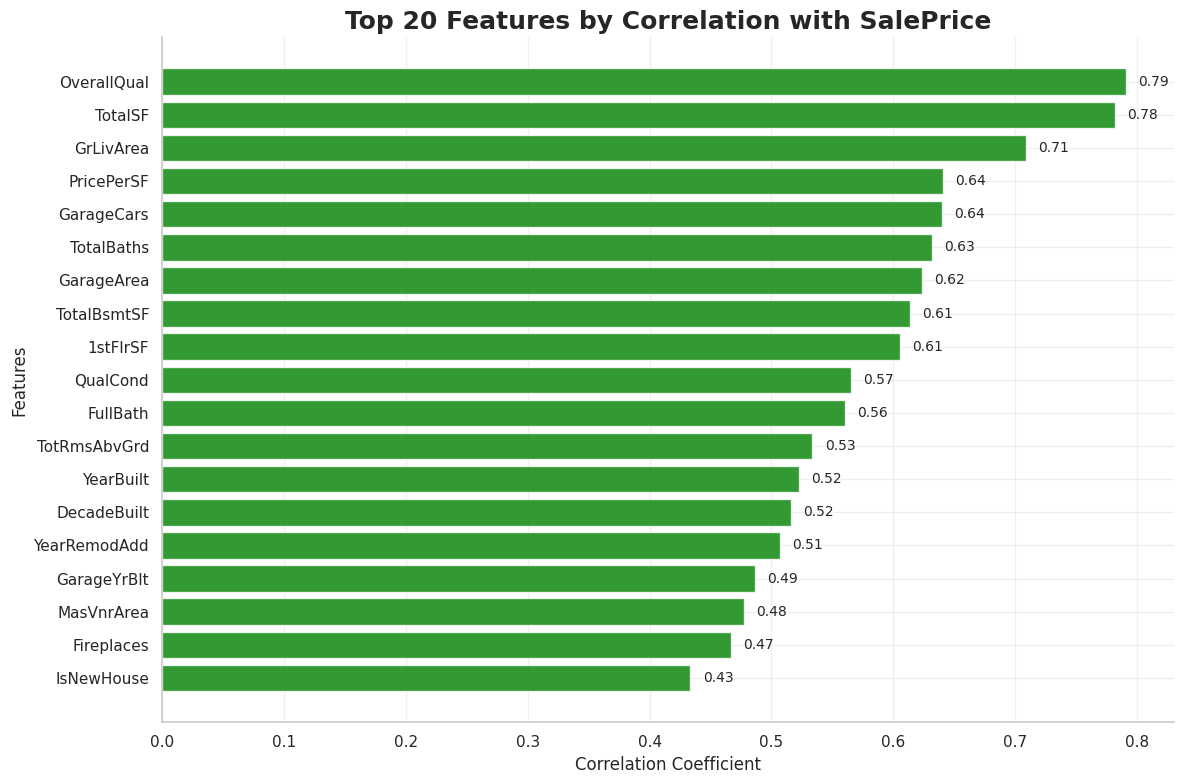


ENGINEERED FEATURE PERFORMANCE

Engineered Features in Top 20:
- TotalSF: 0.782
- TotalBaths: 0.632
- QualCond: 0.565
- PricePerSF: 0.641
- IsNewHouse: 0.434

Interpretation:
5 engineered features entered the top 20 correlations.
This indicates that feature engineering successfully created informative predictive variables.


In [9]:
# =========================================================
# STEP 8 — CORRELATION ANALYSIS OF ENGINEERED FEATURES
# =========================================================

# ---------------------------------------------------------
# SELECT NUMERICAL FEATURES
# ---------------------------------------------------------

numeric_df = df.select_dtypes(include=np.number)


# ---------------------------------------------------------
# COMPUTE CORRELATIONS WITH SALEPRICE
# ---------------------------------------------------------

correlations = (
    numeric_df.corr()['SalePrice']
    .sort_values(ascending=False)
)


# ---------------------------------------------------------
# TOP 20 & BOTTOM 10 FEATURES
# ---------------------------------------------------------

top_20 = correlations.head(20)

bottom_10 = correlations.tail(10)


# ---------------------------------------------------------
# PRINT RESULTS
# ---------------------------------------------------------

print("="*60)
print("TOP 20 FEATURES CORRELATED WITH SALEPRICE")
print("="*60)

print(top_20)

print("\n" + "="*60)
print("BOTTOM 10 FEATURES CORRELATED WITH SALEPRICE")
print("="*60)

print(bottom_10)


# ---------------------------------------------------------
# PREPARE BAR CHART DATA
# ---------------------------------------------------------

top_20_no_target = top_20.drop('SalePrice')

feature_names = top_20_no_target.index
feature_values = top_20_no_target.values

# Color bars
bar_colors = [
    'green' if value > 0 else 'red'
    for value in feature_values
]


# ---------------------------------------------------------
# CREATE HORIZONTAL BAR CHART
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

bars = plt.barh(
    feature_names,
    feature_values,
    color=bar_colors,
    alpha=0.8
)

# Reverse order for readability
plt.gca().invert_yaxis()


# ---------------------------------------------------------
# ADD VALUE LABELS
# ---------------------------------------------------------

for bar in bars:

    width = bar.get_width()

    plt.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center',
        fontsize=10
    )


# ---------------------------------------------------------
# TITLES & LABELS
# ---------------------------------------------------------

plt.title(
    'Top 20 Features by Correlation with SalePrice',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Correlation Coefficient')
plt.ylabel('Features')


# ---------------------------------------------------------
# STYLE CLEANUP
# ---------------------------------------------------------

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(alpha=0.3, axis='x')


# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.tight_layout()

plt.savefig(
    'figures/w3_feature_correlations.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# ---------------------------------------------------------
# CHECK ENGINEERED FEATURES IN TOP 20
# ---------------------------------------------------------

engineered_in_top20 = [
    feature for feature in new_features
    if feature in top_20.index
]


# ---------------------------------------------------------
# PRINT ENGINEERED FEATURE ANALYSIS
# ---------------------------------------------------------

print("\n" + "="*60)
print("ENGINEERED FEATURE PERFORMANCE")
print("="*60)

print("\nEngineered Features in Top 20:")

for feature in engineered_in_top20:

    print(
        f"- {feature}: "
        f"{correlations[feature]:.3f}"
    )


print("\nInterpretation:")

if len(engineered_in_top20) > 0:

    print(
        f"{len(engineered_in_top20)} engineered features "
        f"entered the top 20 correlations."
    )

    print(
        "This indicates that feature engineering successfully "
        "created informative predictive variables."
    )

else:

    print(
        "None of the engineered features entered the top 20."
    )

**Step 9**

In [10]:
# =========================================================
# STEP 9 — CATEGORICAL ANALYSIS & ENCODING STRATEGY
# =========================================================

# ---------------------------------------------------------
# IDENTIFY CATEGORICAL COLUMNS
# ---------------------------------------------------------

categorical_cols = df.select_dtypes(include='object').columns

print("="*60)
print("CATEGORICAL COLUMN ANALYSIS")
print("="*60)

print(f"\nTotal Categorical Columns: {len(categorical_cols)}")


# ---------------------------------------------------------
# DEFINE ORDINAL QUALITY COLUMNS
# ---------------------------------------------------------

ordinal_quality_cols = [
    'ExterQual',
    'ExterCond',
    'BsmtQual',
    'BsmtCond',
    'HeatingQC',
    'KitchenQual',
    'FireplaceQu',
    'GarageQual',
    'GarageCond',
    'PoolQC'
]


# ---------------------------------------------------------
# CREATE ENCODING STRATEGY DICTIONARY
# ---------------------------------------------------------

encoding_strategy = {}


# ---------------------------------------------------------
# ANALYZE EACH CATEGORICAL COLUMN
# ---------------------------------------------------------

for col in categorical_cols:

    print("\n" + "="*60)
    print(f"COLUMN: {col}")
    print("="*60)

    # -----------------------------------------------------
    # UNIQUE CATEGORY COUNT
    # -----------------------------------------------------

    unique_count = df[col].nunique()

    print(f"\nNumber of Unique Categories: {unique_count}")


    # -----------------------------------------------------
    # VALUE COUNTS
    # -----------------------------------------------------

    print("\nValue Counts:")
    print(df[col].value_counts(dropna=False))


    # -----------------------------------------------------
    # MEAN SALEPRICE BY CATEGORY
    # -----------------------------------------------------

    print("\nMean SalePrice by Category:")

    category_price = (
        df.groupby(col)['SalePrice']
        .mean()
        .sort_values(ascending=False)
    )

    print(category_price)


    # -----------------------------------------------------
    # MISSING VALUE PERCENTAGE
    # -----------------------------------------------------

    missing_pct = (
        df[col].isnull().mean() * 100
    )


    # -----------------------------------------------------
    # DOMINANT CATEGORY %
    # -----------------------------------------------------

    dominant_pct = (
        df[col]
        .value_counts(normalize=True, dropna=False)
        .iloc[0] * 100
    )


    # -----------------------------------------------------
    # ENCODING DECISION LOGIC
    # -----------------------------------------------------

    if col in ordinal_quality_cols:

        strategy = 'label_encode'

        reason = 'Ordinal quality scale exists'


    elif missing_pct > 50:

        strategy = 'drop'

        reason = 'More than 50% missing values'


    elif dominant_pct > 95:

        strategy = 'drop'

        reason = 'Single dominant category >95%'


    elif unique_count <= 10:

        strategy = 'onehot_encode'

        reason = 'Nominal feature with low cardinality'


    else:

        strategy = 'frequency_encode'

        reason = 'Nominal feature with high cardinality'


    # Save strategy
    encoding_strategy[col] = {
        'strategy': strategy,
        'unique_categories': unique_count,
        'missing_percent': round(missing_pct, 2),
        'dominant_percent': round(dominant_pct, 2),
        'reason': reason
    }


    # -----------------------------------------------------
    # PRINT DECISION
    # -----------------------------------------------------

    print("\nEncoding Decision:")
    print(f"Strategy: {strategy}")
    print(f"Reason: {reason}")


# =========================================================
# CREATE ENCODING DECISION TABLE
# =========================================================

encoding_df = pd.DataFrame(encoding_strategy).T

# Sort by strategy
encoding_df = encoding_df.sort_values(by='strategy')

print("\n" + "="*80)
print("FINAL ENCODING STRATEGY TABLE")
print("="*80)

display(encoding_df)


# ---------------------------------------------------------
# STRATEGY COUNTS
# ---------------------------------------------------------

print("\n" + "="*60)
print("ENCODING STRATEGY SUMMARY")
print("="*60)

print(
    encoding_df['strategy']
    .value_counts()
)

CATEGORICAL COLUMN ANALYSIS

Total Categorical Columns: 44

COLUMN: MSZoning

Number of Unique Categories: 5

Value Counts:
MSZoning
RL         1151
RM          218
FV           65
RH           16
C (all)      10
Name: count, dtype: int64

Mean SalePrice by Category:
MSZoning
FV         214014.061538
RL         191004.994787
RH         131558.375000
RM         126316.830275
C (all)     74528.000000
Name: SalePrice, dtype: float64

Encoding Decision:
Strategy: onehot_encode
Reason: Nominal feature with low cardinality

COLUMN: Street

Number of Unique Categories: 2

Value Counts:
Street
Pave    1454
Grvl       6
Name: count, dtype: int64

Mean SalePrice by Category:
Street
Pave    181130.538514
Grvl    130190.500000
Name: SalePrice, dtype: float64

Encoding Decision:
Strategy: drop
Reason: Single dominant category >95%

COLUMN: Alley

Number of Unique Categories: 2

Value Counts:
Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64

Mean SalePrice by Category:
Alley
Pa

,strategy,unique_categories,missing_percent,dominant_percent,reason
Street,drop,2,0.0,99.59,Single dominant category >95%
Alley,drop,2,93.77,93.77,More than 50% missing values
MiscFeature,drop,4,96.3,96.3,More than 50% missing values
Fence,drop,4,80.75,80.75,More than 50% missing values
Utilities,drop,2,0.0,99.93,Single dominant category >95%
MasVnrType,drop,3,59.73,59.73,More than 50% missing values
Heating,drop,6,0.0,97.81,Single dominant category >95%
Condition2,drop,8,0.0,98.97,Single dominant category >95%
RoofMatl,drop,8,0.0,98.22,Single dominant category >95%
DecadeLabel,frequency_encode,15,0.0,26.51,Nominal feature with high cardinality



ENCODING STRATEGY SUMMARY
strategy
onehot_encode       21
label_encode        10
drop                 9
frequency_encode     4
Name: count, dtype: int64


**Step 10**

In [11]:
# =========================================================
# STEP 10 — APPLY ALL ENCODING STRATEGIES
# =========================================================

# ---------------------------------------------------------
# CREATE WORKING COPY
# ---------------------------------------------------------

df_encoded = df.copy()

print("="*60)
print("DATA SHAPE BEFORE ENCODING")
print("="*60)

print(df_encoded.shape)


# =========================================================
# (A) LABEL ENCODING
# =========================================================

# ---------------------------------------------------------
# QUALITY MAP
# ---------------------------------------------------------

quality_map = {
    'Ex': 5,
    'Gd': 4,
    'TA': 3,
    'Fa': 2,
    'Po': 1,
    'NA': 0
}

# ---------------------------------------------------------
# LABEL ENCODE QUALITY COLUMNS
# ---------------------------------------------------------

label_columns = [
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'GarageQual',
    'FireplaceQu'
]

print("\n" + "="*60)
print("APPLYING LABEL ENCODING")
print("="*60)

for col in label_columns:

    # Fill missing with 'NA'
    df_encoded[col] = (
        df_encoded[col]
        .fillna('NA')
        .map(quality_map)
    )

    print(f"{col} encoded successfully.")


# =========================================================
# (B) DROP COLUMNS
# =========================================================

# ---------------------------------------------------------
# IDENTIFY DROP COLUMNS
# ---------------------------------------------------------

drop_columns = [
    col for col, info in encoding_strategy.items()
    if info['strategy'] == 'drop'
]

print("\n" + "="*60)
print("DROPPING LOW-INFORMATION COLUMNS")
print("="*60)

print(drop_columns)

# Drop columns
df_encoded.drop(columns=drop_columns, inplace=True)


# =========================================================
# (C) FREQUENCY ENCODING
# =========================================================

# ---------------------------------------------------------
# IDENTIFY FREQUENCY COLUMNS
# ---------------------------------------------------------

frequency_columns = [
    col for col, info in encoding_strategy.items()
    if info['strategy'] == 'frequency_encode'
]

print("\n" + "="*60)
print("APPLYING FREQUENCY ENCODING")
print("="*60)

for col in frequency_columns:

    freq_map = (
        df_encoded[col]
        .value_counts(normalize=True)
    )

    df_encoded[col] = (
        df_encoded[col]
        .map(freq_map)
    )

    print(f"{col} frequency encoded.")


# =========================================================
# (D) ONE-HOT ENCODING
# =========================================================

# ---------------------------------------------------------
# IDENTIFY OHE COLUMNS
# ---------------------------------------------------------

onehot_columns = [
    col for col, info in encoding_strategy.items()
    if info['strategy'] == 'onehot_encode'
]

print("\n" + "="*60)
print("APPLYING ONE-HOT ENCODING")
print("="*60)

print(f"Number of OHE Columns: {len(onehot_columns)}")

# Apply OHE
df_encoded = pd.get_dummies(
    df_encoded,
    columns=onehot_columns,
    drop_first=True
)

print("One-hot encoding completed.")


# =========================================================
# VERIFY OBJECT COLUMNS REMOVED
# =========================================================

remaining_object_cols = (
    df_encoded
    .select_dtypes(include='object')
    .columns
)

print("\n" + "="*60)
print("REMAINING OBJECT COLUMNS")
print("="*60)

print(remaining_object_cols)

if len(remaining_object_cols) == 0:

    print("\nSUCCESS: No object columns remain.")

else:

    print("\nWARNING: Some object columns still exist.")


# =========================================================
# SHAPE COMPARISON
# =========================================================

print("\n" + "="*60)
print("DATA SHAPE AFTER ENCODING")
print("="*60)

print(df_encoded.shape)


# =========================================================
# DIMENSIONALITY CHANGE
# =========================================================

original_cols = df.shape[1]
encoded_cols = df_encoded.shape[1]

print("\n" + "="*60)
print("DIMENSIONALITY ANALYSIS")
print("="*60)

print(f"Original Columns : {original_cols}")
print(f"Encoded Columns  : {encoded_cols}")
print(f"Feature Increase : {encoded_cols - original_cols}")


# =========================================================
# PREVIEW ENCODED DATA
# =========================================================

print("\n" + "="*60)
print("ENCODED DATA PREVIEW")
print("="*60)

display(df_encoded.head())


# =========================================================
# DATA TYPE SUMMARY
# =========================================================

print("\n" + "="*60)
print("DATA TYPE SUMMARY")
print("="*60)

print(df_encoded.dtypes.value_counts())

DATA SHAPE BEFORE ENCODING
(1460, 92)

APPLYING LABEL ENCODING
ExterQual encoded successfully.
KitchenQual encoded successfully.
BsmtQual encoded successfully.
GarageQual encoded successfully.
FireplaceQu encoded successfully.

DROPPING LOW-INFORMATION COLUMNS
['Street', 'Alley', 'Utilities', 'Condition2', 'RoofMatl', 'MasVnrType', 'Heating', 'Fence', 'MiscFeature']

APPLYING FREQUENCY ENCODING
Neighborhood frequency encoded.
Exterior1st frequency encoded.
Exterior2nd frequency encoded.
DecadeLabel frequency encoded.

APPLYING ONE-HOT ENCODING
Number of OHE Columns: 21
One-hot encoding completed.

REMAINING OBJECT COLUMNS
Index(['ExterCond', 'BsmtCond', 'HeatingQC', 'GarageCond', 'PoolQC'], dtype='object')


DATA SHAPE AFTER ENCODING
(1460, 153)

DIMENSIONALITY ANALYSIS
Original Columns : 92
Encoded Columns  : 153
Feature Increase : 61

ENCODED DATA PREVIEW


,Id,MSSubClass,LotFrontage,LotArea,Neighborhood,OverallQual,OverallCond,YearBuilt,YearRemodAdd,Exterior1st,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,60,65.0,8450,0.102740,7,5,2003,2003,0.352740,...,False,False,False,False,True,False,False,False,True,False
1,2,20,80.0,9600,0.007534,6,8,1976,1976,0.150685,...,False,False,False,False,True,False,False,False,True,False
2,3,60,68.0,11250,0.102740,7,5,2001,2002,0.352740,...,False,False,False,False,True,False,False,False,True,False
3,4,70,60.0,9550,0.034932,7,5,1915,1970,0.141096,...,False,False,False,False,True,False,False,False,False,False
4,5,60,84.0,14260,0.028082,8,5,2000,2000,0.352740,...,False,False,False,False,True,False,False,False,True,False



DATA TYPE SUMMARY
bool        91
int64       47
float64      9
object       5
category     1
Name: count, dtype: int64


In [12]:
# =========================================================
# FIX REMAINING ORDINAL OBJECT COLUMNS
# =========================================================

remaining_label_cols = [
    'ExterCond',
    'BsmtCond',
    'HeatingQC',
    'GarageCond',
    'PoolQC'
]

for col in remaining_label_cols:

    df_encoded[col] = (
        df_encoded[col]
        .fillna('NA')
        .map(quality_map)
    )

print("="*60)
print("FIXED REMAINING ORDINAL COLUMNS")
print("="*60)

print("\nRemaining object columns:")

print(
    df_encoded
    .select_dtypes(include='object')
    .columns
)

print("\nUpdated dtype summary:")

print(df_encoded.dtypes.value_counts())

FIXED REMAINING ORDINAL COLUMNS

Remaining object columns:
Index([], dtype='object')

Updated dtype summary:
bool        91
int64       52
float64      9
category     1
Name: count, dtype: int64


In [13]:
# Remove visualization-only category column

if 'OverallQualCategory' in df_encoded.columns:

    df_encoded.drop(
        columns=['OverallQualCategory'],
        inplace=True
    )

print("="*60)
print("FINAL DATA TYPE CHECK")
print("="*60)

print(df_encoded.dtypes.value_counts())

print("\nRemaining non-numeric columns:")

print(
    df_encoded.select_dtypes(
        exclude=np.number
    ).columns
)

FINAL DATA TYPE CHECK
bool       91
int64      52
float64     9
Name: count, dtype: int64

Remaining non-numeric columns:
Index(['MSZoning_FV', 'MSZoning_RH', 'MSZoning_RL', 'MSZoning_RM',
       'LotShape_IR2', 'LotShape_IR3', 'LotShape_Reg', 'LandContour_HLS',
       'LandContour_Low', 'LandContour_Lvl', 'LotConfig_CulDSac',
       'LotConfig_FR2', 'LotConfig_FR3', 'LotConfig_Inside', 'LandSlope_Mod',
       'LandSlope_Sev', 'Condition1_Feedr', 'Condition1_Norm',
       'Condition1_PosA', 'Condition1_PosN', 'Condition1_RRAe',
       'Condition1_RRAn', 'Condition1_RRNe', 'Condition1_RRNn',
       'BldgType_2fmCon', 'BldgType_Duplex', 'BldgType_Twnhs',
       'BldgType_TwnhsE', 'HouseStyle_1.5Unf', 'HouseStyle_1Story',
       'HouseStyle_2.5Fin', 'HouseStyle_2.5Unf', 'HouseStyle_2Story',
       'HouseStyle_SFoyer', 'HouseStyle_SLvl', 'RoofStyle_Gable',
       'RoofStyle_Gambrel', 'RoofStyle_Hip', 'RoofStyle_Mansard',
       'RoofStyle_Shed', 'Foundation_CBlock', 'Foundation_PConc',
   

In [14]:
# =========================================================
# CONVERT BOOLEAN COLUMNS TO INTEGER
# =========================================================

bool_cols = df_encoded.select_dtypes(include='bool').columns

df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("="*60)
print("BOOLEAN COLUMNS CONVERTED TO INTEGER")
print("="*60)

print("\nUpdated dtype summary:")

print(df_encoded.dtypes.value_counts())

print("\nRemaining object columns:")

print(
    df_encoded.select_dtypes(include='object').columns
)

print("\nRemaining category columns:")

print(
    df_encoded.select_dtypes(include='category').columns
)

BOOLEAN COLUMNS CONVERTED TO INTEGER

Updated dtype summary:
int64      143
float64      9
Name: count, dtype: int64

Remaining object columns:
Index([], dtype='object')

Remaining category columns:
Index([], dtype='object')


**Step 11**

TRAIN-TEST SPLIT
X_train shape: (1168, 151)
X_test shape : (292, 151)

SCALING COMPARISON TABLE


,Feature,Original Mean,Original Std,Standard Mean,Standard Std,MinMax Mean,MinMax Std,Robust Mean,Robust Std
0,GrLivArea,1527.402,524.433,-0.0,1.0,0.225,0.099,0.084,0.811
1,TotalSF,2583.477,821.305,0.0,1.0,0.197,0.072,0.091,0.837
2,LotArea,10689.642,10759.366,0.0,1.0,0.044,0.050,0.265,2.615


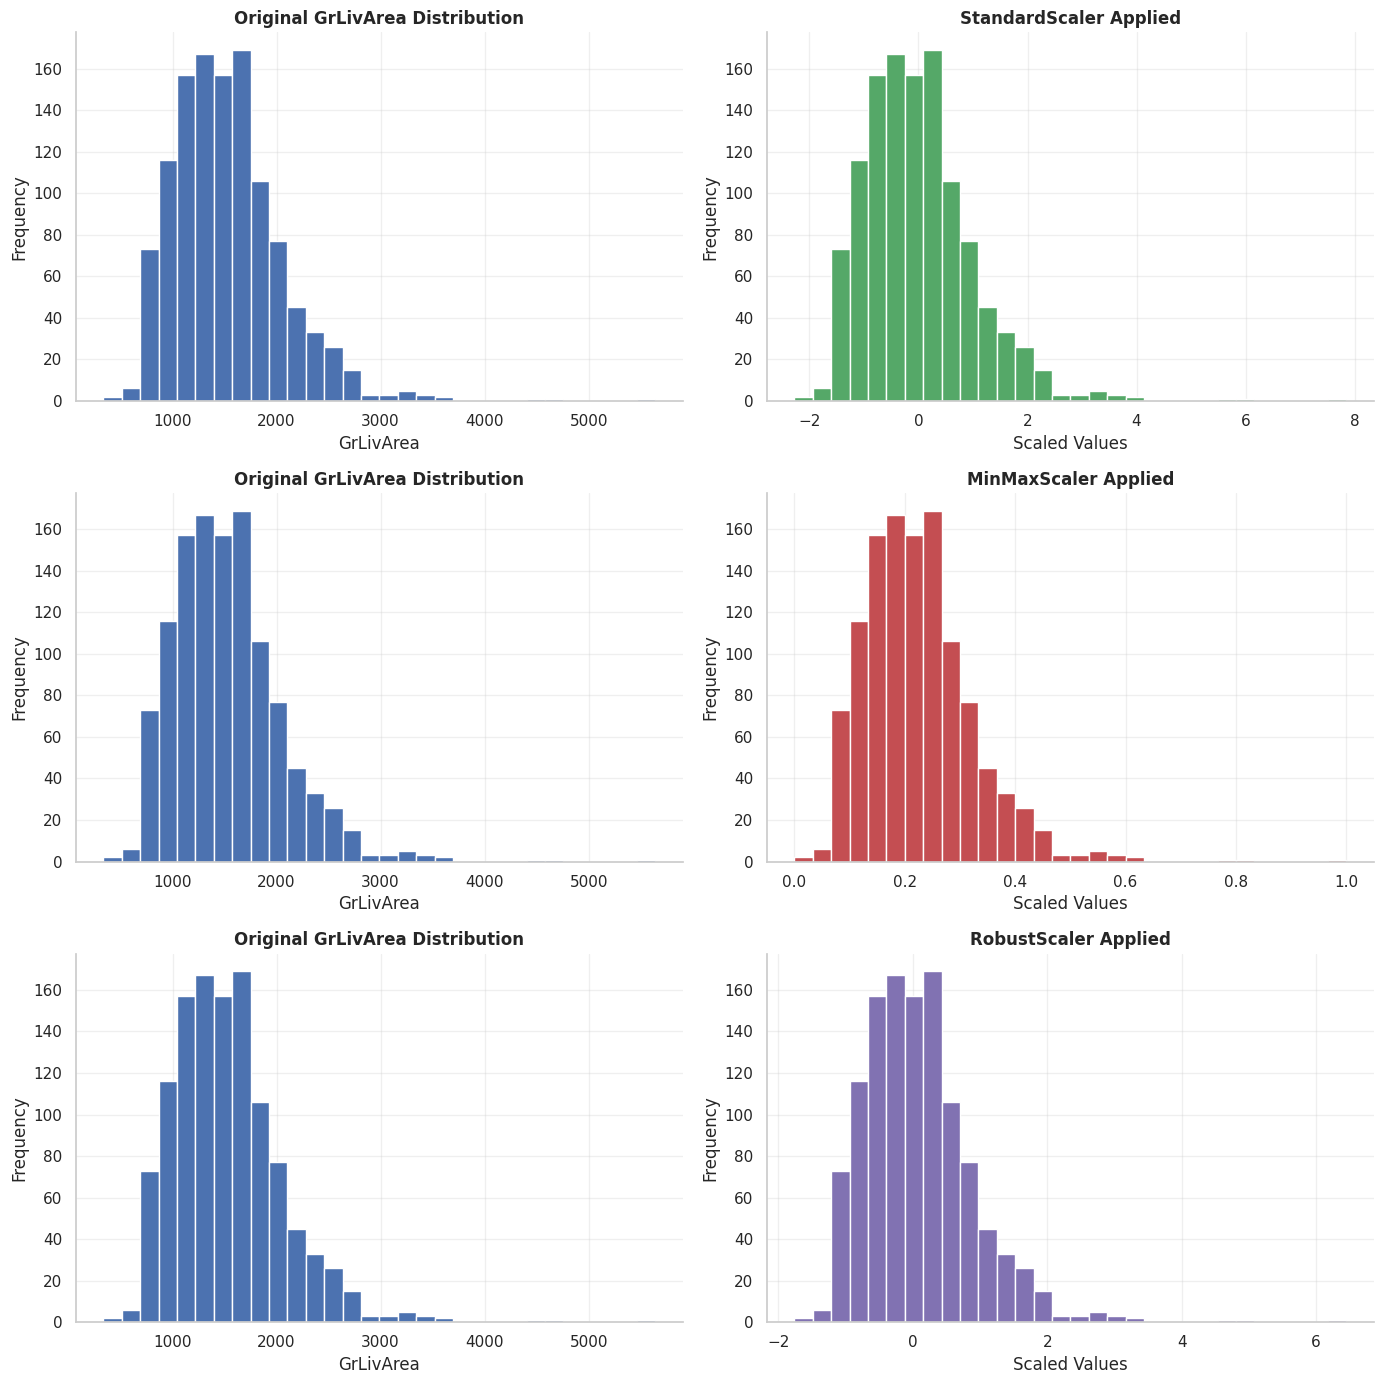


SCALER INTERPRETATION

1. StandardScaler centers data around mean=0 and std=1.
2. MinMaxScaler compresses values into the [0,1] range.
3. RobustScaler uses median and IQR, making it resistant to outliers.

For datasets with strong outliers, RobustScaler is often preferred.
For linear regression and gradient-based models, StandardScaler is commonly used.
Tree-based models generally do not require scaling.



In [15]:
# =========================================================
# STEP 11 — FEATURE SCALING COMPARISON
# =========================================================

from sklearn.model_selection import train_test_split


# =========================================================
# PREPARE FEATURES & TARGET
# =========================================================

# Features
X = df_encoded.drop('SalePrice', axis=1)

# Target
y = df_encoded['SalePrice']


# =========================================================
# TRAIN-TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("="*60)
print("TRAIN-TEST SPLIT")
print("="*60)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape : {X_test.shape}")


# =========================================================
# INITIALIZE SCALERS
# =========================================================

standard_scaler = StandardScaler()

minmax_scaler = MinMaxScaler()

robust_scaler = RobustScaler()


# =========================================================
# APPLY SCALING
# =========================================================

# StandardScaler
X_train_standard = standard_scaler.fit_transform(X_train)
X_test_standard = standard_scaler.transform(X_test)

# MinMaxScaler
X_train_minmax = minmax_scaler.fit_transform(X_train)
X_test_minmax = minmax_scaler.transform(X_test)

# RobustScaler
X_train_robust = robust_scaler.fit_transform(X_train)
X_test_robust = robust_scaler.transform(X_test)


# =========================================================
# SELECT FEATURES FOR COMPARISON
# =========================================================

selected_features = [
    'GrLivArea',
    'TotalSF',
    'LotArea'
]

feature_indices = [
    X.columns.get_loc(col)
    for col in selected_features
]


# =========================================================
# COMPARISON TABLE
# =========================================================

comparison_rows = []

for feature, idx in zip(selected_features, feature_indices):

    comparison_rows.append({
        'Feature': feature,

        'Original Mean':
            X_train.iloc[:, idx].mean(),

        'Original Std':
            X_train.iloc[:, idx].std(),

        'Standard Mean':
            X_train_standard[:, idx].mean(),

        'Standard Std':
            X_train_standard[:, idx].std(),

        'MinMax Mean':
            X_train_minmax[:, idx].mean(),

        'MinMax Std':
            X_train_minmax[:, idx].std(),

        'Robust Mean':
            X_train_robust[:, idx].mean(),

        'Robust Std':
            X_train_robust[:, idx].std()
    })

comparison_df = pd.DataFrame(comparison_rows)


# =========================================================
# DISPLAY COMPARISON TABLE
# =========================================================

print("\n" + "="*80)
print("SCALING COMPARISON TABLE")
print("="*80)

display(
    comparison_df.round(3)
)


# =========================================================
# CREATE HISTOGRAM COMPARISON
# =========================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 14)
)

# =========================================================
# ROW 1 — STANDARD SCALER
# =========================================================

# Before scaling
axes[0, 0].hist(
    X_train['GrLivArea'],
    bins=30,
    color='#4C72B0',
    edgecolor='white'
)

axes[0, 0].set_title(
    'Original GrLivArea Distribution',
    fontweight='bold'
)

axes[0, 0].set_xlabel('GrLivArea')
axes[0, 0].set_ylabel('Frequency')

# After StandardScaler
axes[0, 1].hist(
    X_train_standard[:, X.columns.get_loc('GrLivArea')],
    bins=30,
    color='#55A868',
    edgecolor='white'
)

axes[0, 1].set_title(
    'StandardScaler Applied',
    fontweight='bold'
)

axes[0, 1].set_xlabel('Scaled Values')
axes[0, 1].set_ylabel('Frequency')


# =========================================================
# ROW 2 — MINMAX SCALER
# =========================================================

# Before scaling
axes[1, 0].hist(
    X_train['GrLivArea'],
    bins=30,
    color='#4C72B0',
    edgecolor='white'
)

axes[1, 0].set_title(
    'Original GrLivArea Distribution',
    fontweight='bold'
)

axes[1, 0].set_xlabel('GrLivArea')
axes[1, 0].set_ylabel('Frequency')

# After MinMaxScaler
axes[1, 1].hist(
    X_train_minmax[:, X.columns.get_loc('GrLivArea')],
    bins=30,
    color='#C44E52',
    edgecolor='white'
)

axes[1, 1].set_title(
    'MinMaxScaler Applied',
    fontweight='bold'
)

axes[1, 1].set_xlabel('Scaled Values')
axes[1, 1].set_ylabel('Frequency')


# =========================================================
# ROW 3 — ROBUST SCALER
# =========================================================

# Before scaling
axes[2, 0].hist(
    X_train['GrLivArea'],
    bins=30,
    color='#4C72B0',
    edgecolor='white'
)

axes[2, 0].set_title(
    'Original GrLivArea Distribution',
    fontweight='bold'
)

axes[2, 0].set_xlabel('GrLivArea')
axes[2, 0].set_ylabel('Frequency')

# After RobustScaler
axes[2, 1].hist(
    X_train_robust[:, X.columns.get_loc('GrLivArea')],
    bins=30,
    color='#8172B2',
    edgecolor='white'
)

axes[2, 1].set_title(
    'RobustScaler Applied',
    fontweight='bold'
)

axes[2, 1].set_xlabel('Scaled Values')
axes[2, 1].set_ylabel('Frequency')


# =========================================================
# CLEANUP & LAYOUT
# =========================================================

for ax_row in axes:
    for ax in ax_row:

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.grid(alpha=0.3)

plt.tight_layout()


# =========================================================
# SAVE FIGURE
# =========================================================

plt.savefig(
    'figures/w3_scaling_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# PRINT SCALER INTERPRETATION
# =========================================================

print("\n" + "="*60)
print("SCALER INTERPRETATION")
print("="*60)

print("""
1. StandardScaler centers data around mean=0 and std=1.
2. MinMaxScaler compresses values into the [0,1] range.
3. RobustScaler uses median and IQR, making it resistant to outliers.

For datasets with strong outliers, RobustScaler is often preferred.
For linear regression and gradient-based models, StandardScaler is commonly used.
Tree-based models generally do not require scaling.
""")

**PART C — SKEWNESS TREATMENT & FEATURE SELECTION (STEPS 12–15)**

**Step 12**

SKEWNESS ANALYSIS TABLE


,Feature,Skewness,Severity
128,Functional_Sev,38.210,Very High
122,Electrical_Mix,38.210,Very High
100,RoofStyle_Shed,26.991,Very High
140,SaleType_Con,26.991,Very High
83,Condition1_RRNe,26.991,Very High
...,...,...,...
49,YrSold,0.096,Normal
57,HasRemodeled,0.093,Normal
27,FullBath,0.037,Normal
90,HouseStyle_1Story,0.011,Normal


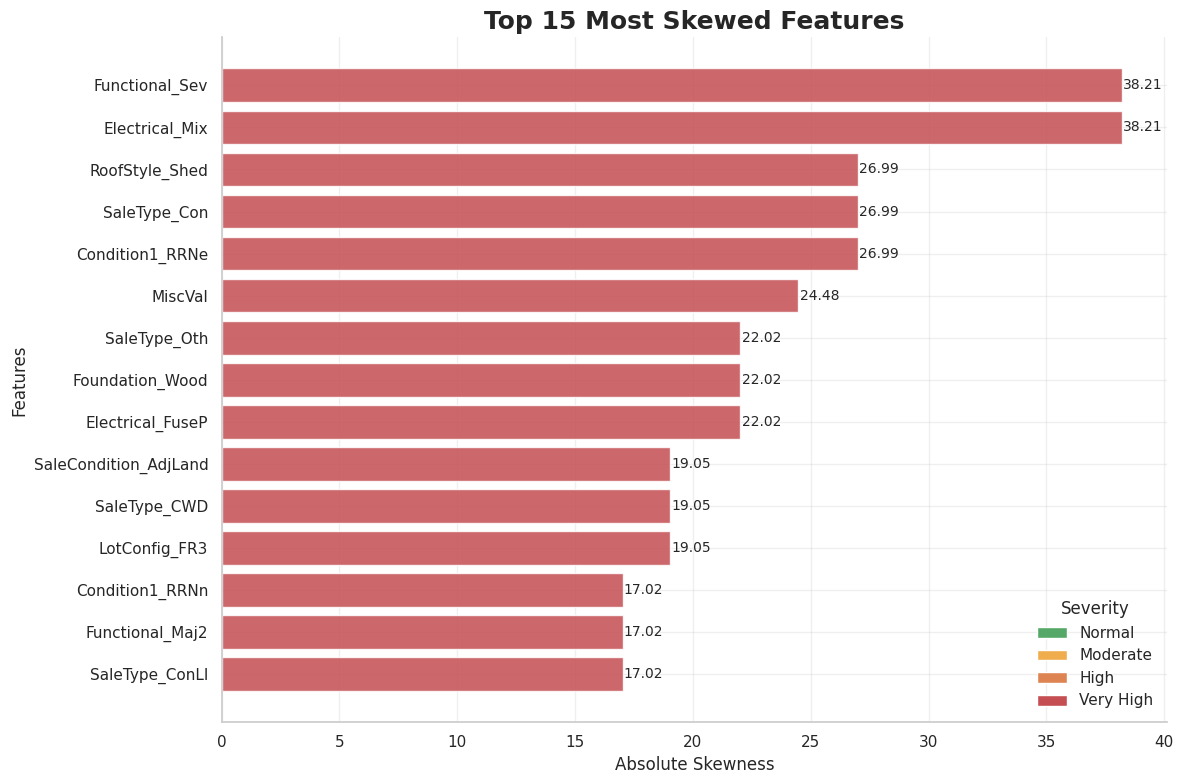


SKEWNESS SUMMARY
Total Numerical Features        : 152
Features with |skew| > 1        : 107
Percentage Highly Skewed        : 70.39%

Skewness Severity Counts:
Severity
Very High    90
Moderate     24
Normal       21
High         17
Name: count, dtype: int64

INTERPRETATION

Highly skewed features may negatively affect:
- Linear regression assumptions
- Gradient-based optimization
- Statistical stability

Logarithmic or Box-Cox transformations can help
reduce skewness and improve feature normality.



In [16]:
# =========================================================
# STEP 12 — SKEWNESS DETECTION & VISUALIZATION
# =========================================================

# ---------------------------------------------------------
# SELECT NUMERICAL FEATURES
# ---------------------------------------------------------

numeric_cols = df_encoded.select_dtypes(include=np.number).columns


# ---------------------------------------------------------
# COMPUTE SKEWNESS
# ---------------------------------------------------------

skew_values = (
    df_encoded[numeric_cols]
    .skew()
)


# ---------------------------------------------------------
# CREATE SKEWNESS TABLE
# ---------------------------------------------------------

skew_df = pd.DataFrame({
    'Feature': skew_values.index,
    'Skewness': skew_values.values
})

# Absolute skewness
skew_df['AbsSkew'] = skew_df['Skewness'].abs()


# ---------------------------------------------------------
# CLASSIFY SKEWNESS SEVERITY
# ---------------------------------------------------------

def classify_skew(skew):

    abs_skew = abs(skew)

    if abs_skew < 0.5:
        return 'Normal'

    elif abs_skew < 1:
        return 'Moderate'

    elif abs_skew < 2:
        return 'High'

    else:
        return 'Very High'


skew_df['Severity'] = (
    skew_df['Skewness']
    .apply(classify_skew)
)


# ---------------------------------------------------------
# SORT BY ABSOLUTE SKEWNESS
# ---------------------------------------------------------

skew_df = skew_df.sort_values(
    by='AbsSkew',
    ascending=False
)


# ---------------------------------------------------------
# DISPLAY SKEWNESS TABLE
# ---------------------------------------------------------

print("="*80)
print("SKEWNESS ANALYSIS TABLE")
print("="*80)

display(
    skew_df[['Feature', 'Skewness', 'Severity']]
    .round(3)
)


# =========================================================
# TOP 15 MOST SKEWED FEATURES
# =========================================================

top_15_skewed = skew_df.head(15)


# ---------------------------------------------------------
# COLOR MAPPING
# ---------------------------------------------------------

severity_colors = {
    'Normal': '#55A868',
    'Moderate': '#F0AD4E',
    'High': '#DD8452',
    'Very High': '#C44E52'
}

bar_colors = [
    severity_colors[sev]
    for sev in top_15_skewed['Severity']
]


# ---------------------------------------------------------
# CREATE HORIZONTAL BAR CHART
# ---------------------------------------------------------

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_15_skewed['Feature'],
    top_15_skewed['AbsSkew'],
    color=bar_colors,
    alpha=0.85
)

# Reverse order
plt.gca().invert_yaxis()


# ---------------------------------------------------------
# ADD VALUE LABELS
# ---------------------------------------------------------

for bar, skew in zip(bars, top_15_skewed['Skewness']):

    width = bar.get_width()

    plt.text(
        width + 0.05,
        bar.get_y() + bar.get_height()/2,
        f'{skew:.2f}',
        va='center',
        fontsize=10
    )


# ---------------------------------------------------------
# TITLES & LABELS
# ---------------------------------------------------------

plt.title(
    'Top 15 Most Skewed Features',
    fontsize=18,
    fontweight='bold'
)

plt.xlabel('Absolute Skewness')
plt.ylabel('Features')


# ---------------------------------------------------------
# CREATE CUSTOM LEGEND
# ---------------------------------------------------------

from matplotlib.patches import Patch

legend_elements = [
    Patch(facecolor=color, label=label)
    for label, color in severity_colors.items()
]

plt.legend(
    handles=legend_elements,
    title='Severity'
)


# ---------------------------------------------------------
# STYLE CLEANUP
# ---------------------------------------------------------

ax = plt.gca()

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.grid(alpha=0.3, axis='x')


# ---------------------------------------------------------
# SAVE FIGURE
# ---------------------------------------------------------

plt.tight_layout()

plt.savefig(
    'figures/w3_skewness_analysis.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# SKEWNESS STATISTICS
# =========================================================

# Features with |skew| > 1
high_skew_count = (
    skew_df['AbsSkew'] > 1
).sum()

# Total numerical features
total_numeric = len(skew_df)

# Percentage
high_skew_pct = (
    high_skew_count / total_numeric
) * 100


# =========================================================
# PRINT SUMMARY
# =========================================================

print("\n" + "="*60)
print("SKEWNESS SUMMARY")
print("="*60)

print(f"Total Numerical Features        : {total_numeric}")

print(f"Features with |skew| > 1        : {high_skew_count}")

print(f"Percentage Highly Skewed        : {high_skew_pct:.2f}%")


# ---------------------------------------------------------
# SEVERITY COUNTS
# ---------------------------------------------------------

print("\nSkewness Severity Counts:")

print(
    skew_df['Severity']
    .value_counts()
)


# =========================================================
# INTERPRETATION
# =========================================================

print("\n" + "="*60)
print("INTERPRETATION")
print("="*60)

print("""
Highly skewed features may negatively affect:
- Linear regression assumptions
- Gradient-based optimization
- Statistical stability

Logarithmic or Box-Cox transformations can help
reduce skewness and improve feature normality.
""")

**Step 13**

HIGHLY SKEWED CONTINUOUS FEATURES


,0
MiscVal,24.477
LotArea,12.208
3SsnPorch,10.304
LowQualFinSF,9.011
BsmtFinSF2,4.255
ScreenPorch,4.122
EnclosedPorch,3.090
MasVnrArea,2.669
OpenPorchSF,2.364
LotFrontage,2.164



SALEPRICE TRANSFORMATION COMPARISON
Original  : 1.8829
Log1p     : 0.1213
Sqrt      : 0.9432
BoxCox    : -0.0087

Best Transformation: BoxCox


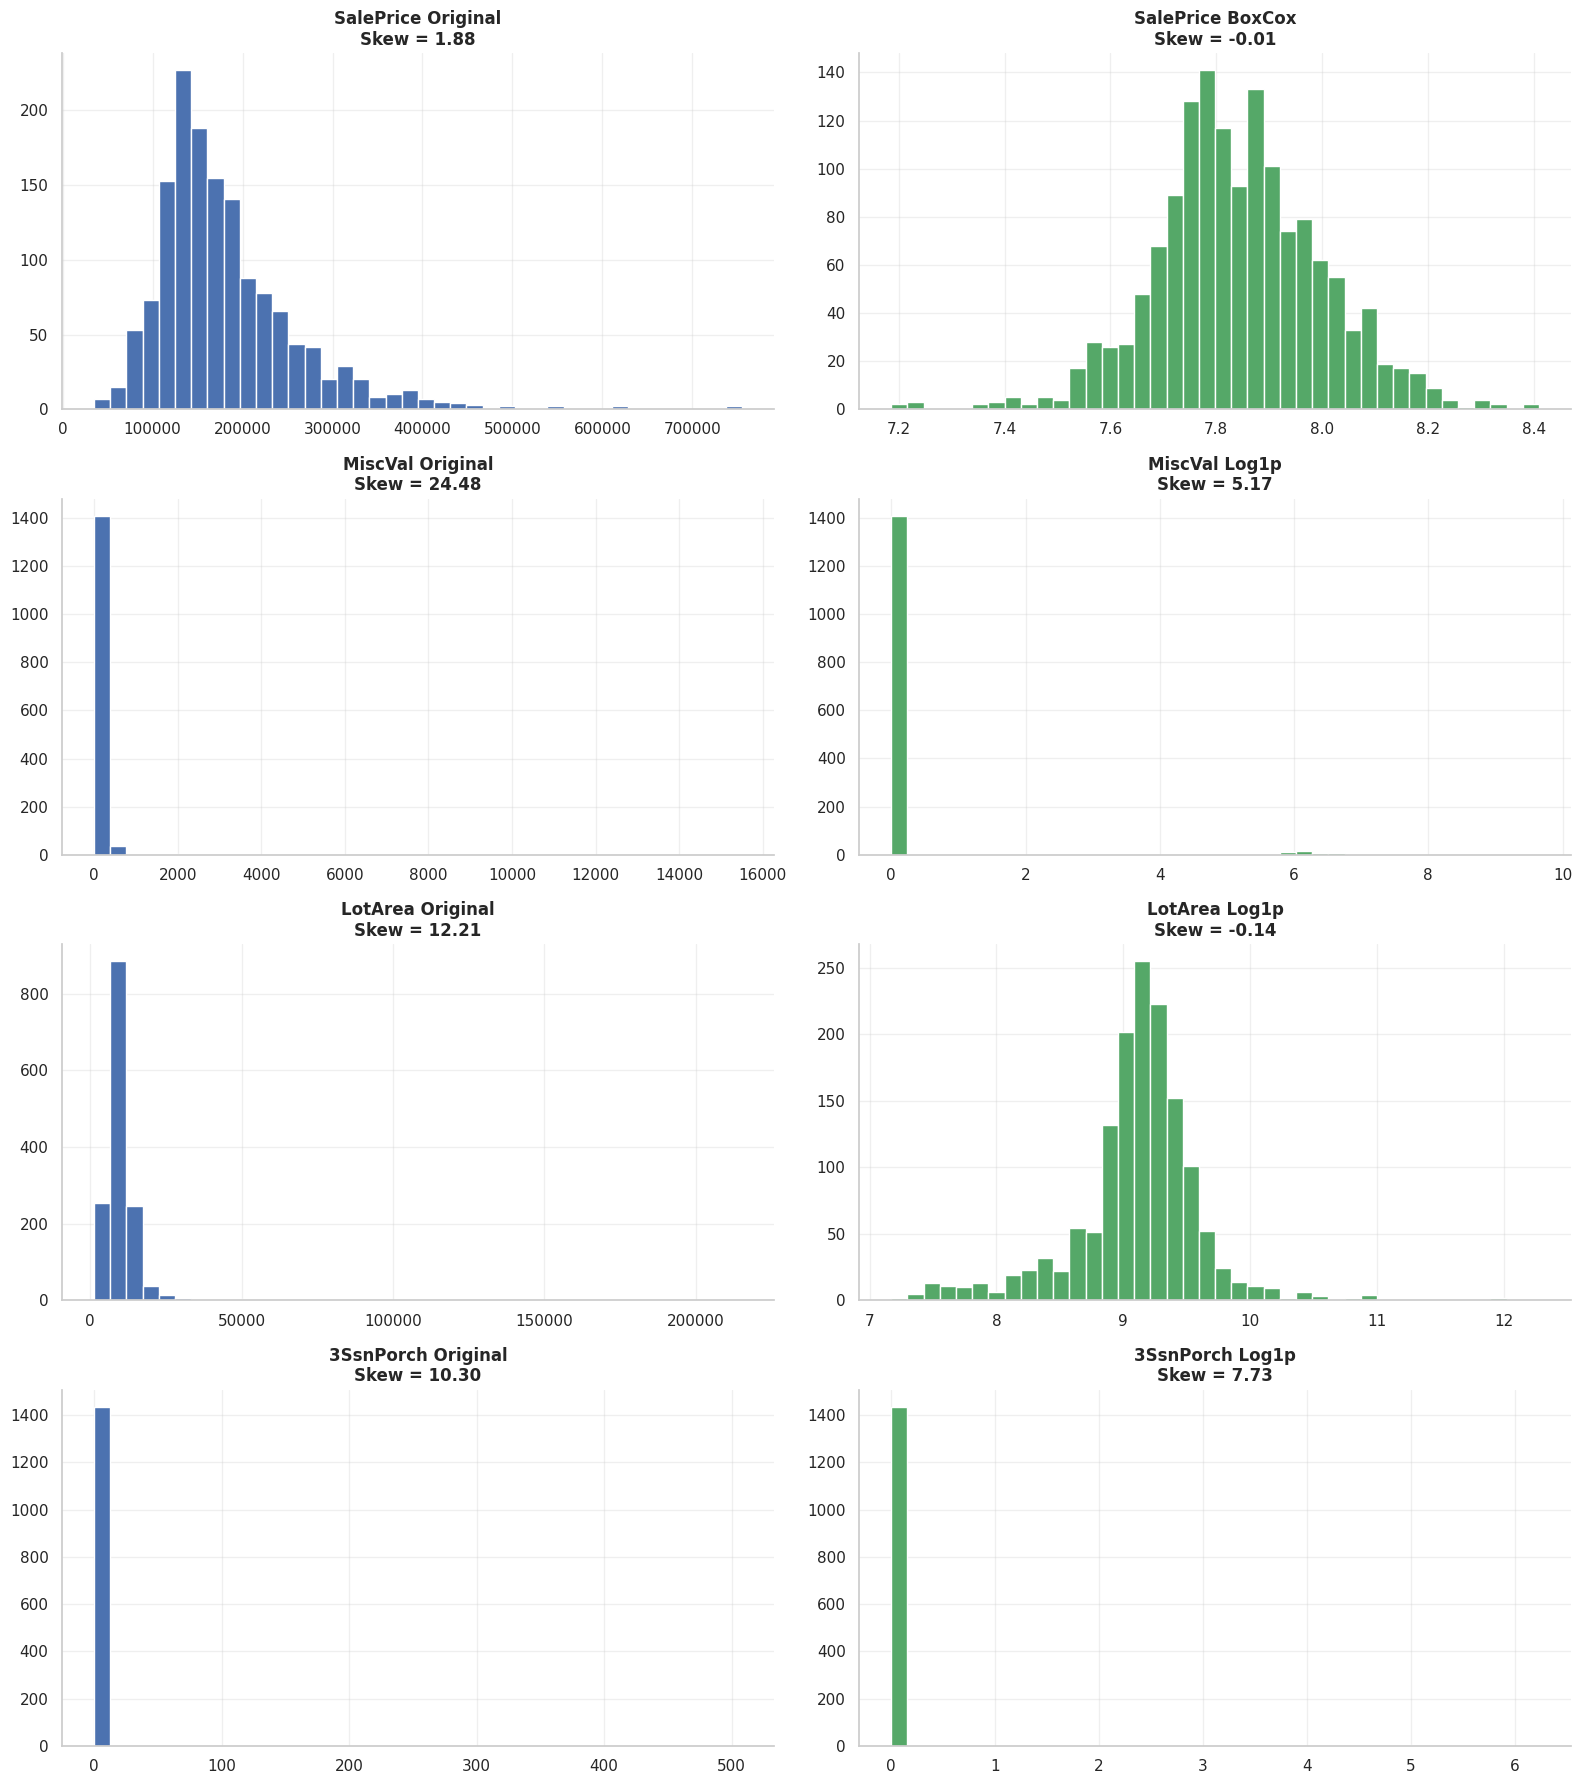


TRANSFORMATION SUMMARY
Number of transformed features: 18

Transformed Features:
- MiscVal
- LotArea
- 3SsnPorch
- LowQualFinSF
- BsmtFinSF2
- ScreenPorch
- EnclosedPorch
- OpenPorchSF
- TotalSF
- BsmtFinSF1
- WoodDeckSF
- TotalBsmtSF
- MSSubClass
- 1stFlrSF
- GrLivArea
- BsmtUnfSF
- Neighborhood
- 2ndFlrSF

INTERPRETATION

Logarithmic transformations substantially reduce right-skewness
by compressing extreme values and stabilizing variance.

Box-Cox transformation often performs best for strictly positive
continuous variables because it optimizes the transformation
parameter mathematically.

Reducing skewness improves:
- regression assumptions
- statistical stability
- optimization performance
- coefficient interpretability



In [17]:
# =========================================================
# STEP 13 — SKEWNESS TRANSFORMATIONS
# =========================================================

from scipy.stats import boxcox


# =========================================================
# IDENTIFY HIGHLY SKEWED CONTINUOUS FEATURES
# =========================================================

# Exclude binary / dummy variables
continuous_features = []

for col in df_encoded.columns:

    unique_values = df_encoded[col].nunique()

    # Keep only non-binary numerical features
    if unique_values > 10:
        continuous_features.append(col)


# ---------------------------------------------------------
# COMPUTE SKEWNESS
# ---------------------------------------------------------

continuous_skew = (
    df_encoded[continuous_features]
    .skew()
    .sort_values(key=abs, ascending=False)
)

# Select features with |skew| > 0.75
high_skew_features = (
    continuous_skew[
        continuous_skew.abs() > 0.75
    ]
)

print("="*70)
print("HIGHLY SKEWED CONTINUOUS FEATURES")
print("="*70)

display(
    high_skew_features
    .round(3)
)


# =========================================================
# APPLY LOG1P TRANSFORMATIONS
# =========================================================

df_transformed = df_encoded.copy()

transformed_features = []

for col in high_skew_features.index:

    # Skip SalePrice for separate analysis
    if col != 'SalePrice':

        # Ensure non-negative
        if (df_transformed[col] >= 0).all():

            df_transformed[col] = np.log1p(
                df_transformed[col]
            )

            transformed_features.append(col)


# =========================================================
# SALEPRICE TRANSFORMATION COMPARISON
# =========================================================

saleprice_original = df_encoded['SalePrice']

# log1p
saleprice_log = np.log1p(saleprice_original)

# sqrt
saleprice_sqrt = np.sqrt(saleprice_original)

# Box-Cox
saleprice_boxcox, lambda_bc = boxcox(
    saleprice_original
)

# ---------------------------------------------------------
# COMPUTE SKEWNESS VALUES
# ---------------------------------------------------------

saleprice_skews = {
    'Original': saleprice_original.skew(),
    'Log1p': pd.Series(saleprice_log).skew(),
    'Sqrt': pd.Series(saleprice_sqrt).skew(),
    'BoxCox': pd.Series(saleprice_boxcox).skew()
}


# =========================================================
# DETERMINE BEST TRANSFORMATION
# =========================================================

best_transform = min(
    saleprice_skews,
    key=lambda k: abs(saleprice_skews[k])
)

print("\n" + "="*70)
print("SALEPRICE TRANSFORMATION COMPARISON")
print("="*70)

for method, skew_val in saleprice_skews.items():

    print(f"{method:<10}: {skew_val:.4f}")

print(f"\nBest Transformation: {best_transform}")


# =========================================================
# SAVE BEST TRANSFORMATION
# =========================================================

if best_transform == 'Log1p':

    df_transformed['SalePrice_transformed'] = saleprice_log

elif best_transform == 'Sqrt':

    df_transformed['SalePrice_transformed'] = saleprice_sqrt

else:

    df_transformed['SalePrice_transformed'] = saleprice_boxcox


# =========================================================
# SELECT 3 HIGHLY SKEWED FEATURES FOR VISUALIZATION
# =========================================================

visual_features = []

for feature in high_skew_features.index:

    if feature != 'SalePrice':

        visual_features.append(feature)

    if len(visual_features) == 3:
        break


# =========================================================
# CREATE 4x2 VISUALIZATION
# =========================================================

fig, axes = plt.subplots(
    4,
    2,
    figsize=(16, 18)
)

# =========================================================
# ROW 1 — SALEPRICE
# =========================================================

# Original
axes[0, 0].hist(
    saleprice_original,
    bins=40,
    color='#4C72B0',
    edgecolor='white'
)

axes[0, 0].set_title(
    f'SalePrice Original\nSkew = {saleprice_skews["Original"]:.2f}',
    fontweight='bold'
)

# Transformed
axes[0, 1].hist(
    df_transformed['SalePrice_transformed'],
    bins=40,
    color='#55A868',
    edgecolor='white'
)

axes[0, 1].set_title(
    f'SalePrice {best_transform}\nSkew = {saleprice_skews[best_transform]:.2f}',
    fontweight='bold'
)


# =========================================================
# REMAINING 3 FEATURES
# =========================================================

for i, feature in enumerate(visual_features, start=1):

    # Original
    axes[i, 0].hist(
        df_encoded[feature],
        bins=40,
        color='#4C72B0',
        edgecolor='white'
    )

    original_skew = df_encoded[feature].skew()

    axes[i, 0].set_title(
        f'{feature} Original\nSkew = {original_skew:.2f}',
        fontweight='bold'
    )


    # Transformed
    transformed_skew = (
        df_transformed[feature]
        .skew()
    )

    axes[i, 1].hist(
        df_transformed[feature],
        bins=40,
        color='#55A868',
        edgecolor='white'
    )

    axes[i, 1].set_title(
        f'{feature} Log1p\nSkew = {transformed_skew:.2f}',
        fontweight='bold'
    )


# =========================================================
# CLEANUP
# =========================================================

for row in axes:
    for ax in row:

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

        ax.grid(alpha=0.3)


plt.tight_layout()


# =========================================================
# SAVE FIGURE
# =========================================================

plt.savefig(
    'figures/w3_skewness_transformations.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# TRANSFORMATION SUMMARY
# =========================================================

print("\n" + "="*70)
print("TRANSFORMATION SUMMARY")
print("="*70)

print(f"Number of transformed features: {len(transformed_features)}")

print("\nTransformed Features:")

for feature in transformed_features:
    print(f"- {feature}")


# =========================================================
# INTERPRETATION
# =========================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

print("""
Logarithmic transformations substantially reduce right-skewness
by compressing extreme values and stabilizing variance.

Box-Cox transformation often performs best for strictly positive
continuous variables because it optimizes the transformation
parameter mathematically.

Reducing skewness improves:
- regression assumptions
- statistical stability
- optimization performance
- coefficient interpretability
""")

**Step 14**

In [18]:
# =========================================================
# STEP 14 — FEATURE SELECTION PIPELINE
# =========================================================

from sklearn.feature_selection import VarianceThreshold


# =========================================================
# PREPARE TARGET
# =========================================================

# Use transformed SalePrice if available
target_col = 'SalePrice_transformed'

if target_col not in df_transformed.columns:
    target_col = 'SalePrice'

print("="*70)
print("TARGET COLUMN")
print("="*70)

print(f"Using target: {target_col}")


# =========================================================
# CORRELATION-BASED SELECTION
# =========================================================

# Compute correlations
correlations = (
    df_transformed
    .corr()[target_col]
    .abs()
    .sort_values(ascending=False)
)

# Remove target itself
correlations = correlations.drop(target_col)

# Keep top 30
top_30_features = correlations.head(30).index.tolist()

print("\n" + "="*70)
print("TOP 30 FEATURES BY CORRELATION")
print("="*70)

for i, feature in enumerate(top_30_features, start=1):

    print(
        f"{i:2d}. "
        f"{feature:<25} "
        f"{correlations[feature]:.3f}"
    )


# =========================================================
# CREATE FEATURE SUBSET
# =========================================================

X_selected = df_transformed[top_30_features]


# =========================================================
# VARIANCE THRESHOLD
# =========================================================

variance_selector = VarianceThreshold(
    threshold=0.01
)

variance_selector.fit(X_selected)

# Keep features above threshold
variance_features = (
    X_selected.columns[
        variance_selector.get_support()
    ]
)

X_variance = X_selected[variance_features]

print("\n" + "="*70)
print("VARIANCE THRESHOLD RESULTS")
print("="*70)

print(f"Features before variance filtering : {X_selected.shape[1]}")
print(f"Features after variance filtering  : {X_variance.shape[1]}")

removed_variance = (
    set(X_selected.columns)
    - set(X_variance.columns)
)

print("\nRemoved Low-Variance Features:")

if len(removed_variance) == 0:
    print("None")
else:
    for feat in removed_variance:
        print(f"- {feat}")


# =========================================================
# MULTICOLLINEARITY REMOVAL
# =========================================================

# Correlation matrix
corr_matrix = X_variance.corr().abs()

# Upper triangle
upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

# Features to drop
to_drop = []

for col in upper_triangle.columns:

    high_corr_features = upper_triangle.index[
        upper_triangle[col] > 0.95
    ].tolist()

    for row_feature in high_corr_features:

        # Compare correlation with target
        corr_row = correlations[row_feature]
        corr_col = correlations[col]

        # Drop weaker feature
        if corr_row > corr_col:
            weaker = col
        else:
            weaker = row_feature

        if weaker not in to_drop:
            to_drop.append(weaker)


# =========================================================
# REMOVE MULTICOLLINEAR FEATURES
# =========================================================

X_final = X_variance.drop(
    columns=to_drop,
    errors='ignore'
)

print("\n" + "="*70)
print("MULTICOLLINEARITY REMOVAL")
print("="*70)

print(f"Features before multicollinearity removal : {X_variance.shape[1]}")
print(f"Features after multicollinearity removal  : {X_final.shape[1]}")

print("\nDropped Multicollinear Features:")

if len(to_drop) == 0:
    print("None")
else:
    for feat in to_drop:
        print(f"- {feat}")


# =========================================================
# FINAL FEATURE SUMMARY
# =========================================================

final_feature_df = pd.DataFrame({
    'Feature': X_final.columns,
    'CorrelationWithTarget': [
        correlations[feat]
        for feat in X_final.columns
    ],
    'DataType': [
        str(X_final[feat].dtype)
        for feat in X_final.columns
    ]
})

final_feature_df = final_feature_df.sort_values(
    by='CorrelationWithTarget',
    ascending=False
)

print("\n" + "="*70)
print("FINAL FEATURE SET")
print("="*70)

display(
    final_feature_df
    .round(3)
)


# =========================================================
# FEATURE REDUCTION STATISTICS
# =========================================================

original_feature_count = (
    df_transformed.shape[1] - 1
)

final_feature_count = X_final.shape[1]

eliminated_count = (
    original_feature_count
    - final_feature_count
)

eliminated_pct = (
    eliminated_count
    / original_feature_count
) * 100

print("\n" + "="*70)
print("FEATURE REDUCTION SUMMARY")
print("="*70)

print(f"Original Features           : {original_feature_count}")

print(f"Final Selected Features     : {final_feature_count}")

print(f"Eliminated Features         : {eliminated_count}")

print(f"Percentage Eliminated       : {eliminated_pct:.2f}%")


# =========================================================
# SAVE FINAL FEATURE LIST
# =========================================================

final_selected_features = (
    X_final.columns.tolist()
)


# =========================================================
# INTERPRETATION
# =========================================================

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

print("""
Feature selection reduces:
- dimensionality
- redundancy
- multicollinearity
- noise

Correlation filtering preserves predictive power,
while variance thresholding removes near-constant features.

Removing multicollinear variables improves:
- model stability
- coefficient interpretability
- regression robustness
""")

TARGET COLUMN
Using target: SalePrice_transformed

TOP 30 FEATURES BY CORRELATION
 1. SalePrice                 0.940
 2. OverallQual               0.815
 3. TotalSF                   0.807
 4. GrLivArea                 0.729
 5. GarageCars                0.680
 6. ExterQual                 0.674
 7. TotalBaths                0.673
 8. KitchenQual               0.665
 9. GarageArea                0.650
10. PricePerSF                0.628
11. BsmtQual                  0.615
12. QualCond                  0.608
13. 1stFlrSF                  0.608
14. FullBath                  0.594
15. HouseAge                  0.589
16. YearBuilt                 0.588
17. DecadeBuilt               0.580
18. RemodelAge                0.569
19. YearRemodAdd              0.567
20. FireplaceQu               0.545
21. GarageYrBlt               0.543
22. TotRmsAbvGrd              0.532
23. Foundation_PConc          0.530
24. DecadeLabel               0.499
25. Fireplaces                0.489
26. HeatingQC     

,Feature,CorrelationWithTarget,DataType
0,SalePrice,0.940,int64
1,OverallQual,0.815,int64
2,TotalSF,0.807,float64
3,GrLivArea,0.729,float64
4,GarageCars,0.680,int64
5,ExterQual,0.674,int64
6,TotalBaths,0.673,float64
7,KitchenQual,0.665,int64
8,GarageArea,0.650,int64
9,PricePerSF,0.628,float64



FEATURE REDUCTION SUMMARY
Original Features           : 152
Final Selected Features     : 26
Eliminated Features         : 126
Percentage Eliminated       : 82.89%

INTERPRETATION

Feature selection reduces:
- dimensionality
- redundancy
- multicollinearity
- noise

Correlation filtering preserves predictive power,
while variance thresholding removes near-constant features.

Removing multicollinear variables improves:
- model stability
- coefficient interpretability
- regression robustness



In [19]:
# =========================================================
# FIX TARGET LEAKAGE
# =========================================================

# Remove original SalePrice from final features
if 'SalePrice' in X_final.columns:

    X_final = X_final.drop(columns=['SalePrice'])

    print("SalePrice removed to prevent target leakage.")


# ---------------------------------------------------------
# UPDATE FINAL FEATURE LIST
# ---------------------------------------------------------

final_selected_features = X_final.columns.tolist()


# ---------------------------------------------------------
# UPDATED FEATURE COUNT
# ---------------------------------------------------------

final_feature_count = len(final_selected_features)

print("\nUpdated Final Feature Count:")
print(final_feature_count)


# ---------------------------------------------------------
# DISPLAY FINAL FEATURES
# ---------------------------------------------------------

print("\nFinal Selected Features:\n")

for i, feat in enumerate(final_selected_features, start=1):
    print(f"{i:2d}. {feat}")

SalePrice removed to prevent target leakage.

Updated Final Feature Count:
25

Final Selected Features:

 1. OverallQual
 2. TotalSF
 3. GrLivArea
 4. GarageCars
 5. ExterQual
 6. TotalBaths
 7. KitchenQual
 8. GarageArea
 9. PricePerSF
10. BsmtQual
11. QualCond
12. 1stFlrSF
13. FullBath
14. HouseAge
15. RemodelAge
16. FireplaceQu
17. GarageYrBlt
18. TotRmsAbvGrd
19. Foundation_PConc
20. Fireplaces
21. HeatingQC
22. OpenPorchSF
23. IsNewHouse
24. BsmtFinType1_GLQ
25. GarageFinish_Unf


**Step 15**

FUNCTION 1 TEST — visualize_distributions


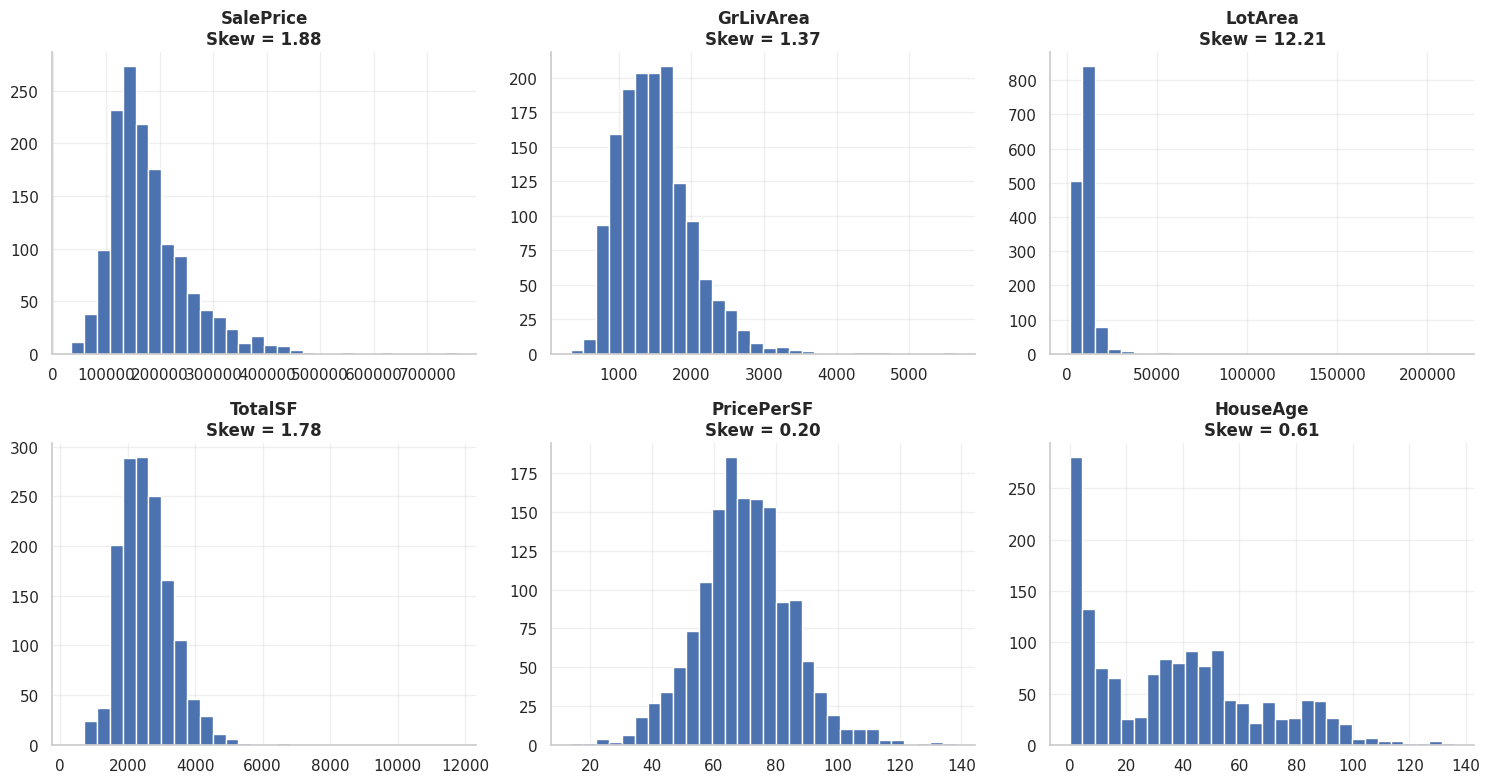


FUNCTION 2 TEST — encode_quality_column
Mapping Used:
{'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'NA': 0}

Encoded Values Preview:


,Original,Encoded
0,Gd,4
1,TA,3
2,Gd,4
3,Gd,4
4,Gd,4
5,TA,3
6,Gd,4
7,TA,3
8,TA,3
9,TA,3



FUNCTION 3 TEST — full_scaling_pipeline
Scaling Method Used: StandardScaler

X_train_scaled shape: (1000, 25)
X_test_scaled shape : (460, 25)

First 5 rows of scaled data:


,OverallQual,TotalSF,GrLivArea,GarageCars,ExterQual,TotalBaths,KitchenQual,GarageArea,PricePerSF,BsmtQual,...,FireplaceQu,GarageYrBlt,TotRmsAbvGrd,Foundation_PConc,Fireplaces,HeatingQC,OpenPorchSF,IsNewHouse,BsmtFinType1_GLQ,GarageFinish_Unf
0,0.633,0.152,0.539,0.316,1.020,1.633,0.726,0.358,0.709,0.559,...,-0.995,0.981,0.936,1.112,-0.939,0.898,0.847,1.945,1.565,-0.844
1,-0.090,0.099,-0.377,0.316,-0.689,0.359,-0.765,-0.064,0.105,0.559,...,0.674,-0.108,-0.308,-0.899,0.600,0.898,-1.048,-0.514,-0.639,-0.844
2,0.633,0.322,0.670,0.316,1.020,1.633,0.726,0.645,0.796,0.559,...,0.674,0.901,-0.308,1.112,0.600,0.898,0.679,-0.514,1.565,-0.844
3,0.633,0.033,0.551,1.663,-0.689,-0.278,0.726,0.808,-0.885,-0.587,...,1.230,0.780,0.314,-0.899,0.600,-0.159,0.598,-0.514,-0.639,1.185
4,1.356,0.998,1.296,1.663,1.020,1.633,0.726,1.737,0.291,0.559,...,0.674,0.860,1.558,1.112,0.600,0.898,0.992,-0.514,1.565,-0.844



STEP 15 SUMMARY

Three reusable feature engineering functions were successfully built:

1. visualize_distributions()
   -> Automated histogram dashboard with skewness annotations

2. encode_quality_column()
   -> Reusable ordinal encoding utility

3. full_scaling_pipeline()
   -> Flexible train-test scaling pipeline

These reusable utilities improve:
- code modularity
- maintainability
- reproducibility
- scalability of ML preprocessing workflows



In [20]:
# =========================================================
# STEP 15 — REUSABLE FEATURE ENGINEERING FUNCTIONS
# =========================================================

from typing import Optional, Tuple, Dict

from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler
)


# =========================================================
# FUNCTION 1
# =========================================================

def visualize_distributions(
    df: pd.DataFrame,
    cols: list,
    n_cols: int = 3
) -> None:
    """
    Create a multi-panel histogram visualization
    for numerical columns with skewness annotations.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.

    cols : list
        List of numerical columns to visualize.

    n_cols : int, default=3
        Number of subplot columns.

    Returns
    -------
    None
    """

    n_features = len(cols)

    n_rows = int(
        np.ceil(n_features / n_cols)
    )

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(5*n_cols, 4*n_rows)
    )

    axes = np.array(axes).reshape(-1)

    for i, col in enumerate(cols):

        skew_val = df[col].skew()

        axes[i].hist(
            df[col].dropna(),
            bins=30,
            color='#4C72B0',
            edgecolor='white'
        )

        axes[i].set_title(
            f'{col}\nSkew = {skew_val:.2f}',
            fontweight='bold'
        )

        axes[i].grid(alpha=0.3)

        axes[i].spines['top'].set_visible(False)
        axes[i].spines['right'].set_visible(False)

    # Remove empty subplots
    for j in range(i+1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


# =========================================================
# FUNCTION 2
# =========================================================

def encode_quality_column(
    series: pd.Series,
    quality_map: Optional[Dict[str, int]] = None
) -> Tuple[pd.Series, Dict[str, int]]:
    """
    Encode ordinal quality categories into numerical values.

    Parameters
    ----------
    series : pd.Series
        Categorical quality column.

    quality_map : dict, optional
        Custom mapping dictionary.

    Returns
    -------
    encoded_series : pd.Series
        Encoded numerical series.

    mapping_used : dict
        Mapping dictionary applied.
    """

    # Default quality mapping
    default_map = {
        'Ex': 5,
        'Gd': 4,
        'TA': 3,
        'Fa': 2,
        'Po': 1,
        'NA': 0
    }

    mapping_used = (
        quality_map
        if quality_map is not None
        else default_map
    )

    encoded_series = (
        series
        .fillna('NA')
        .map(mapping_used)
    )

    return encoded_series, mapping_used


# =========================================================
# FUNCTION 3
# =========================================================

def full_scaling_pipeline(
    X_train: pd.DataFrame,
    X_test: pd.DataFrame,
    method: str = 'standard'
):
    """
    Apply scaling transformation to train and test data.

    Parameters
    ----------
    X_train : pd.DataFrame
        Training feature matrix.

    X_test : pd.DataFrame
        Testing feature matrix.

    method : str, default='standard'
        Scaling method:
        - 'standard'
        - 'minmax'
        - 'robust'

    Returns
    -------
    X_train_scaled : np.ndarray
        Scaled training data.

    X_test_scaled : np.ndarray
        Scaled testing data.

    scaler : object
        Fitted scaler object.
    """

    if method == 'standard':

        scaler = StandardScaler()

    elif method == 'minmax':

        scaler = MinMaxScaler()

    elif method == 'robust':

        scaler = RobustScaler()

    else:

        raise ValueError(
            "method must be "
            "'standard', 'minmax', or 'robust'"
        )

    # Fit on training data
    X_train_scaled = scaler.fit_transform(X_train)

    # Transform testing data
    X_test_scaled = scaler.transform(X_test)

    return (
        X_train_scaled,
        X_test_scaled,
        scaler
    )


# =========================================================
# FUNCTION TESTING & DEMONSTRATION
# =========================================================

print("="*70)
print("FUNCTION 1 TEST — visualize_distributions")
print("="*70)

distribution_cols = [
    'SalePrice',
    'GrLivArea',
    'LotArea',
    'TotalSF',
    'PricePerSF',
    'HouseAge'
]

visualize_distributions(
    df_encoded,
    distribution_cols,
    n_cols=3
)


# =========================================================
# FUNCTION 2 TEST
# =========================================================

print("\n" + "="*70)
print("FUNCTION 2 TEST — encode_quality_column")
print("="*70)

encoded_kitchen, used_mapping = encode_quality_column(
    df['KitchenQual']
)

print("Mapping Used:")

print(used_mapping)

print("\nEncoded Values Preview:")

display(
    pd.DataFrame({
        'Original': df['KitchenQual'].head(10),
        'Encoded': encoded_kitchen.head(10)
    })
)


# =========================================================
# FUNCTION 3 TEST
# =========================================================

print("\n" + "="*70)
print("FUNCTION 3 TEST — full_scaling_pipeline")
print("="*70)

# Use final selected features
X_train_final = X_final.iloc[:1000]
X_test_final = X_final.iloc[1000:]

# Apply scaling
X_train_scaled, X_test_scaled, fitted_scaler = (
    full_scaling_pipeline(
        X_train_final,
        X_test_final,
        method='standard'
    )
)

print("Scaling Method Used: StandardScaler")

print(f"\nX_train_scaled shape: {X_train_scaled.shape}")

print(f"X_test_scaled shape : {X_test_scaled.shape}")

print("\nFirst 5 rows of scaled data:")

display(
    pd.DataFrame(
        X_train_scaled[:5],
        columns=X_train_final.columns
    ).round(3)
)


# =========================================================
# FINAL SUMMARY
# =========================================================

print("\n" + "="*70)
print("STEP 15 SUMMARY")
print("="*70)

print("""
Three reusable feature engineering functions were successfully built:

1. visualize_distributions()
   -> Automated histogram dashboard with skewness annotations

2. encode_quality_column()
   -> Reusable ordinal encoding utility

3. full_scaling_pipeline()
   -> Flexible train-test scaling pipeline

These reusable utilities improve:
- code modularity
- maintainability
- reproducibility
- scalability of ML preprocessing workflows
""")

**PART D — PROFESSIONAL DASHBOARD & WRITTEN REPORT**

**Step 16**

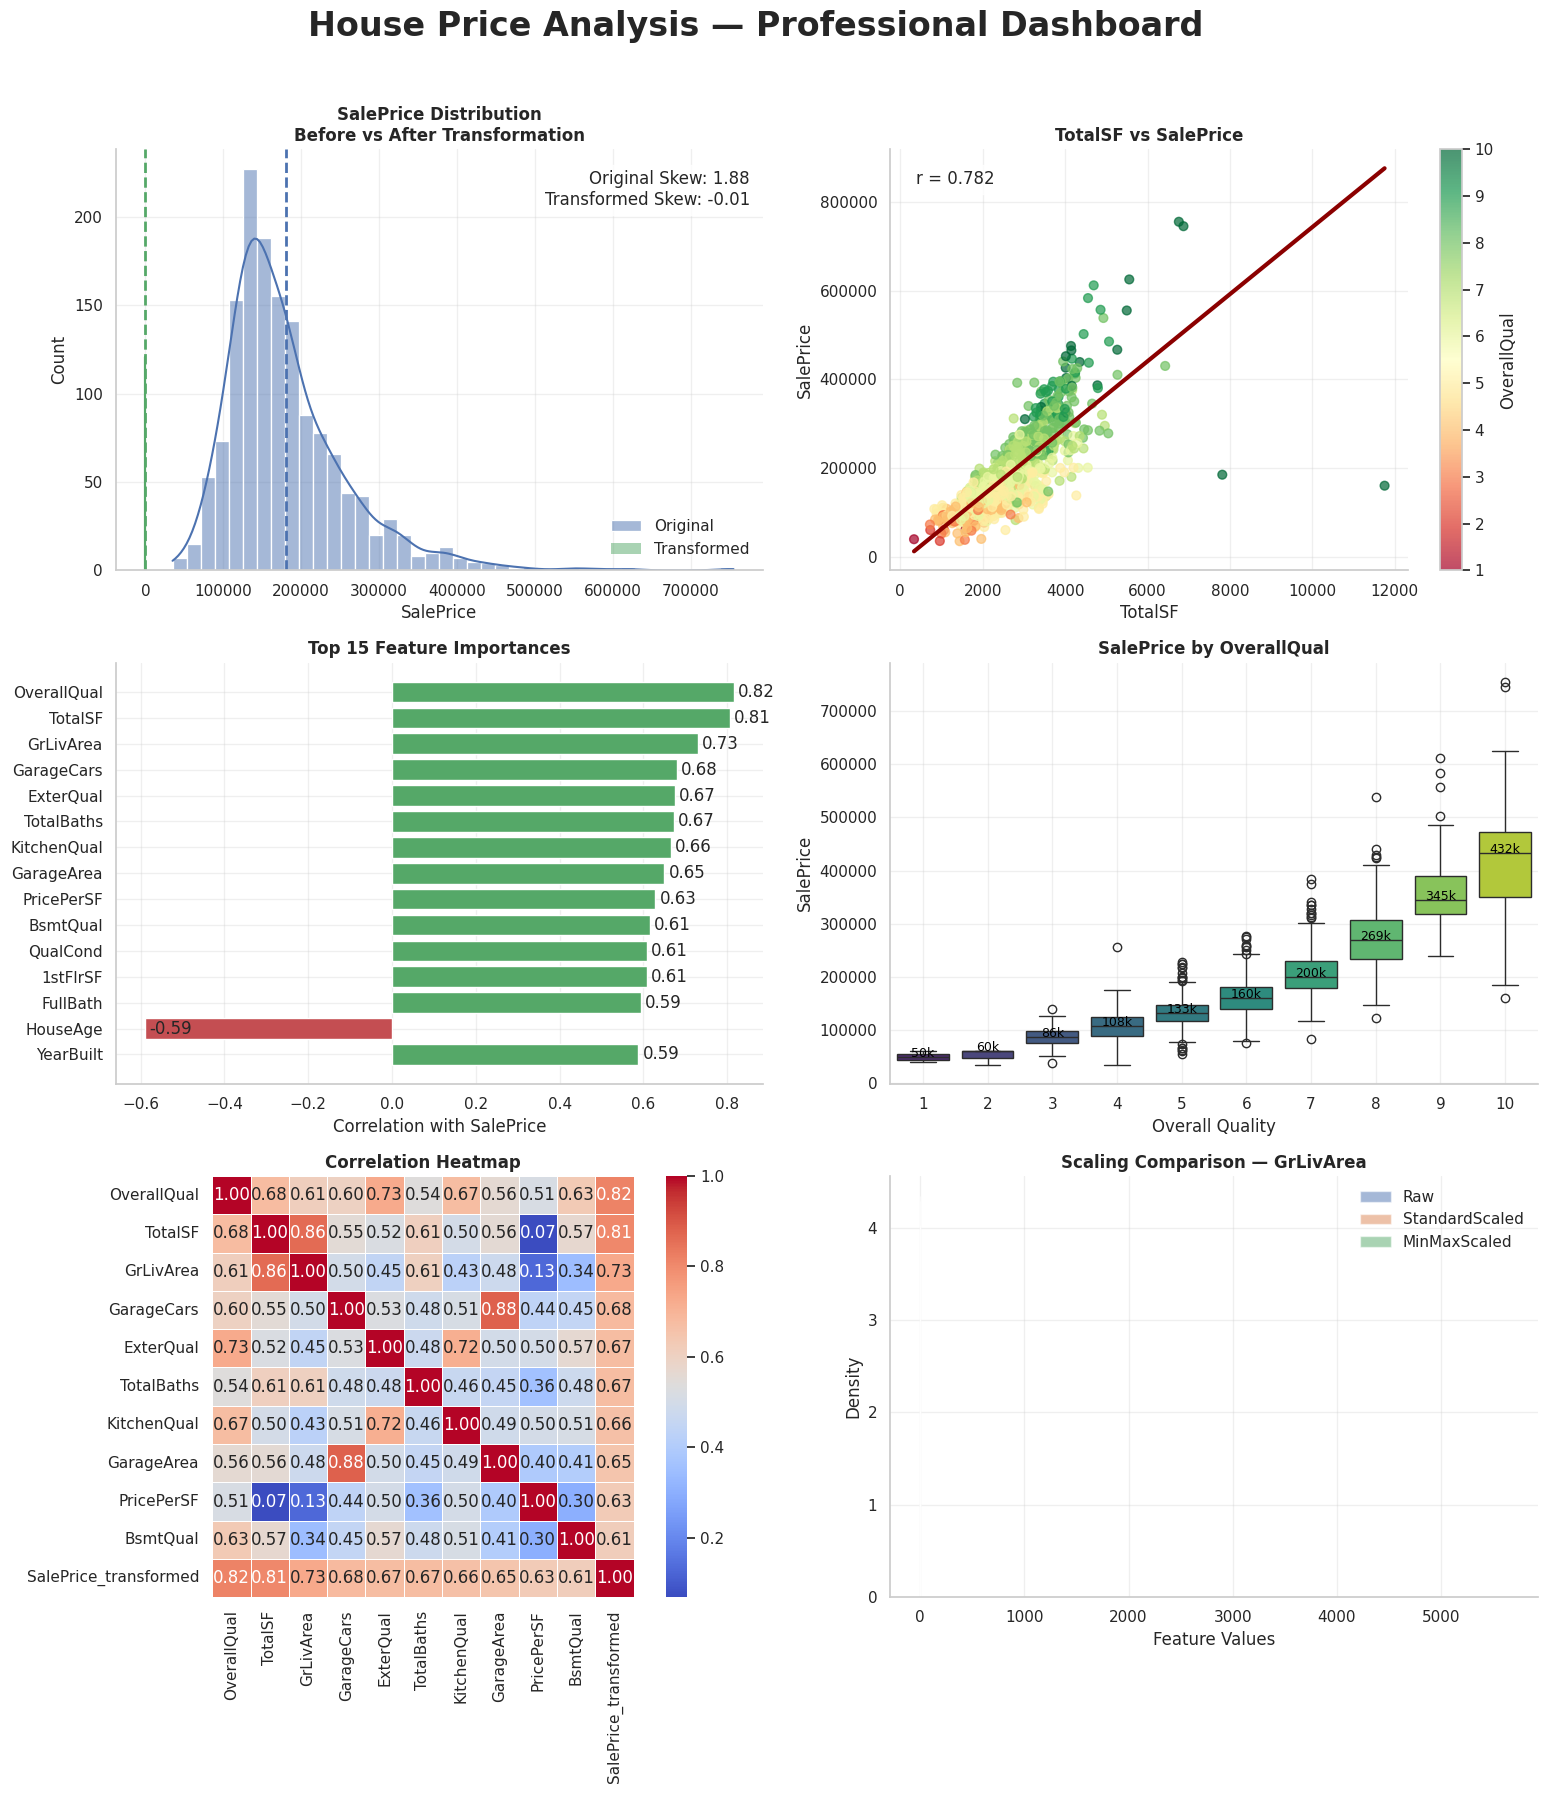

FINAL DASHBOARD SUMMARY

Dashboard Components:
1. SalePrice transformation analysis
2. TotalSF vs SalePrice relationship
3. Top feature importance ranking
4. SalePrice by OverallQual
5. Correlation heatmap
6. Scaling comparison

The dashboard integrates:
- EDA
- feature engineering
- transformations
- scaling analysis
- feature importance analysis

into a single professional visualization report.



In [22]:
# =========================================================
# STEP 16 — FINAL PROFESSIONAL DASHBOARD
# =========================================================

from scipy.stats import gaussian_kde


# =========================================================
# CREATE DASHBOARD FIGURE
# =========================================================

fig, axes = plt.subplots(
    3,
    2,
    figsize=(16, 18)
)

fig.suptitle(
    'House Price Analysis — Professional Dashboard',
    fontsize=24,
    fontweight='bold',
    y=0.995
)

# =========================================================
# CHART 1 — SALEPRICE BEFORE/AFTER TRANSFORMATION
# =========================================================

ax1 = axes[0, 0]

# Original
sns.histplot(
    df_encoded['SalePrice'],
    bins=40,
    kde=True,
    color='#4C72B0',
    alpha=0.5,
    ax=ax1,
    label='Original'
)

# Transformed
sns.histplot(
    df_transformed['SalePrice_transformed'],
    bins=40,
    kde=True,
    color='#55A868',
    alpha=0.5,
    ax=ax1,
    label='Transformed'
)

# Mean lines
ax1.axvline(
    df_encoded['SalePrice'].mean(),
    color='#4C72B0',
    linestyle='--',
    linewidth=2
)

ax1.axvline(
    df_transformed['SalePrice_transformed'].mean(),
    color='#55A868',
    linestyle='--',
    linewidth=2
)

# Skewness
orig_skew = df_encoded['SalePrice'].skew()

trans_skew = (
    df_transformed['SalePrice_transformed']
    .skew()
)

ax1.text(
    0.98,
    0.95,
    f'Original Skew: {orig_skew:.2f}\n'
    f'Transformed Skew: {trans_skew:.2f}',
    transform=ax1.transAxes,
    ha='right',
    va='top',
    bbox=dict(
        facecolor='white',
        alpha=0.8
    )
)

ax1.set_title(
    'SalePrice Distribution\nBefore vs After Transformation',
    fontweight='bold'
)

ax1.legend()


# =========================================================
# CHART 2 — TOTALSF VS SALEPRICE
# =========================================================

ax2 = axes[0, 1]

scatter = ax2.scatter(
    df_encoded['TotalSF'],
    df_encoded['SalePrice'],
    c=df_encoded['OverallQual'],
    cmap='RdYlGn',
    alpha=0.7,
    s=40
)

# Regression line
z = np.polyfit(
    df_encoded['TotalSF'],
    df_encoded['SalePrice'],
    1
)

p = np.poly1d(z)

x_line = np.linspace(
    df_encoded['TotalSF'].min(),
    df_encoded['TotalSF'].max(),
    200
)

ax2.plot(
    x_line,
    p(x_line),
    color='darkred',
    linewidth=3
)

# Correlation
r_value = (
    df_encoded['TotalSF']
    .corr(df_encoded['SalePrice'])
)

ax2.text(
    0.05,
    0.95,
    f'r = {r_value:.3f}',
    transform=ax2.transAxes,
    fontsize=12,
    va='top',
    bbox=dict(
        facecolor='white',
        alpha=0.8
    )
)

ax2.set_title(
    'TotalSF vs SalePrice',
    fontweight='bold'
)

ax2.set_xlabel('TotalSF')
ax2.set_ylabel('SalePrice')

cbar = fig.colorbar(
    scatter,
    ax=ax2
)

cbar.set_label('OverallQual')


# =========================================================
# CHART 3 — TOP 15 FEATURE IMPORTANCES
# =========================================================

ax3 = axes[1, 0]

# Correlations
feature_corr = (
    df_transformed
    .corr()['SalePrice_transformed']
    .drop('SalePrice_transformed')
)

top_15 = (
    feature_corr
    .drop('SalePrice', errors='ignore')
    .abs()
    .sort_values(ascending=False)
    .head(15)
)

top_15_values = feature_corr[top_15.index]

# Colors
colors = [
    '#55A868' if val > 0 else '#C44E52'
    for val in top_15_values
]

bars = ax3.barh(
    top_15.index,
    top_15_values.values,
    color=colors
)

ax3.invert_yaxis()

# Value labels
for bar in bars:

    width = bar.get_width()

    ax3.text(
        width + 0.01,
        bar.get_y() + bar.get_height()/2,
        f'{width:.2f}',
        va='center'
    )

ax3.set_title(
    'Top 15 Feature Importances',
    fontweight='bold'
)

ax3.set_xlabel('Correlation with SalePrice')


# =========================================================
# CHART 4 — BOXPLOTS BY OVERALLQUAL
# =========================================================

ax4 = axes[1, 1]

palette = sns.color_palette(
    'viridis',
    n_colors=10
)

sns.boxplot(
    data=df_encoded,
    x='OverallQual',
    y='SalePrice',
    palette=palette,
    ax=ax4
)

# Median labels
medians = (
    df_encoded
    .groupby('OverallQual')['SalePrice']
    .median()
)

for xtick in ax4.get_xticks():

    qual = xtick + 1

    if qual in medians.index:

        median_val = medians[qual]

        ax4.text(
            xtick,
            median_val,
            f'{int(median_val/1000)}k',
            ha='center',
            fontsize=9,
            color='black'
        )

ax4.set_title(
    'SalePrice by OverallQual',
    fontweight='bold'
)

ax4.set_xlabel('Overall Quality')
ax4.set_ylabel('SalePrice')


# =========================================================
# CHART 5 — CORRELATION HEATMAP
# =========================================================

ax5 = axes[2, 0]

heatmap_features = (
    top_15.index[:10]
    .tolist()
)

heatmap_features.append(
    'SalePrice_transformed'
)

corr_matrix = (
    df_transformed[heatmap_features]
    .corr()
)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    square=True,
    linewidths=0.5,
    ax=ax5
)

ax5.set_title(
    'Correlation Heatmap',
    fontweight='bold'
)


# =========================================================
# CHART 6 — SCALING COMPARISON
# =========================================================

ax6 = axes[2, 1]

# Raw distribution
ax6.hist(
    X_train['GrLivArea'],
    bins=30,
    alpha=0.5,
    density=True,
    label='Raw'
)

# StandardScaler
ax6.hist(
    X_train_standard[:, X.columns.get_loc('GrLivArea')],
    bins=30,
    alpha=0.5,
    density=True,
    label='StandardScaled'
)

# MinMaxScaler
ax6.hist(
    X_train_minmax[:, X.columns.get_loc('GrLivArea')],
    bins=30,
    alpha=0.5,
    density=True,
    label='MinMaxScaled'
)

ax6.set_title(
    'Scaling Comparison — GrLivArea',
    fontweight='bold'
)

ax6.set_xlabel('Feature Values')
ax6.set_ylabel('Density')

ax6.legend()


# =========================================================
# GLOBAL STYLING
# =========================================================

for row in axes:

    for ax in row:

        ax.grid(alpha=0.3)

        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)


# =========================================================
# FINAL LAYOUT
# =========================================================

plt.tight_layout(
    rect=[0, 0, 1, 0.98]
)


# =========================================================
# SAVE DASHBOARD
# =========================================================

plt.savefig(
    'figures/week3_dashboard.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# DASHBOARD SUMMARY
# =========================================================

print("="*70)
print("FINAL DASHBOARD SUMMARY")
print("="*70)

print("""
Dashboard Components:
1. SalePrice transformation analysis
2. TotalSF vs SalePrice relationship
3. Top feature importance ranking
4. SalePrice by OverallQual
5. Correlation heatmap
6. Scaling comparison

The dashboard integrates:
- EDA
- feature engineering
- transformations
- scaling analysis
- feature importance analysis

into a single professional visualization report.
""")

**Step 17**

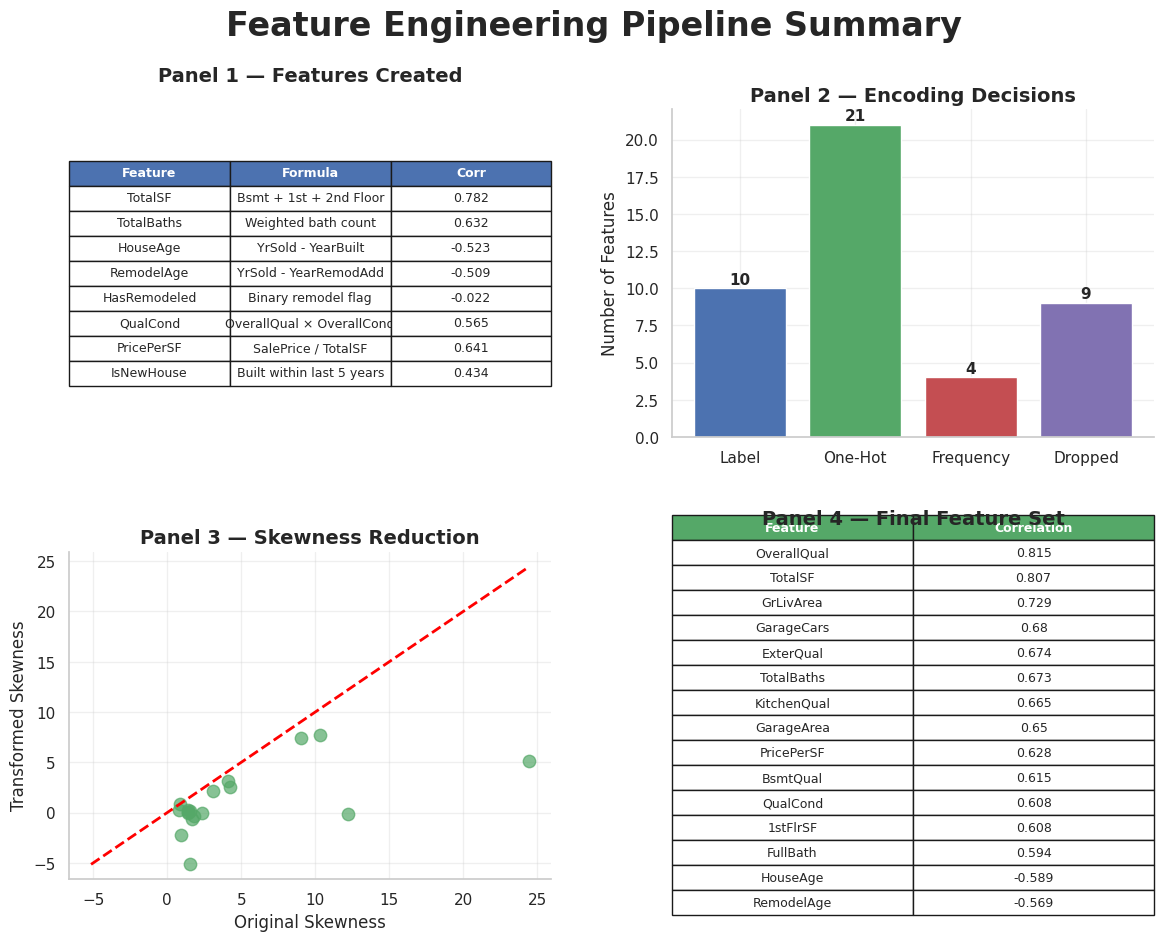

FEATURE ENGINEERING PIPELINE SUMMARY

Panels Included:
1. Engineered features summary table
2. Encoding strategy decisions
3. Skewness reduction visualization
4. Final selected feature set

Key Pipeline Highlights:
- 8 engineered features created
- Multiple encoding strategies applied
- Skewness reduced through transformations
- Feature selection eliminated redundant variables
- Final optimized feature set prepared for ML

Saved File:
figures/week3_fe_pipeline.png



In [23]:
# =========================================================
# STEP 17 — FEATURE ENGINEERING SUMMARY INFOGRAPHIC
# =========================================================

from matplotlib.patches import Rectangle


# =========================================================
# CREATE FIGURE
# =========================================================

fig = plt.figure(figsize=(14, 10))

fig.suptitle(
    'Feature Engineering Pipeline Summary',
    fontsize=24,
    fontweight='bold',
    y=0.98
)

# Grid layout
gs = fig.add_gridspec(
    2,
    2,
    hspace=0.35,
    wspace=0.25
)

# =========================================================
# PANEL 1 — ENGINEERED FEATURES TABLE
# =========================================================

ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')

engineered_features = [
    'TotalSF',
    'TotalBaths',
    'HouseAge',
    'RemodelAge',
    'HasRemodeled',
    'QualCond',
    'PricePerSF',
    'IsNewHouse'
]

feature_formulas = [
    'Bsmt + 1st + 2nd Floor',
    'Weighted bath count',
    'YrSold - YearBuilt',
    'YrSold - YearRemodAdd',
    'Binary remodel flag',
    'OverallQual × OverallCond',
    'SalePrice / TotalSF',
    'Built within last 5 years'
]

feature_corrs = [
    round(df_encoded[feat].corr(df_encoded['SalePrice']), 3)
    for feat in engineered_features
]

table_data = pd.DataFrame({
    'Feature': engineered_features,
    'Formula': feature_formulas,
    'Corr': feature_corrs
})

table = ax1.table(
    cellText=table_data.values,
    colLabels=table_data.columns,
    loc='center',
    cellLoc='center'
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

# Header styling
for (row, col), cell in table.get_celld().items():

    if row == 0:

        cell.set_facecolor('#4C72B0')
        cell.set_text_props(
            color='white',
            weight='bold'
        )

ax1.set_title(
    'Panel 1 — Features Created',
    fontsize=14,
    fontweight='bold',
    pad=20
)


# =========================================================
# PANEL 2 — ENCODING DECISIONS
# =========================================================

ax2 = fig.add_subplot(gs[0, 1])

encoding_counts = {
    'Label': 10,
    'One-Hot': 21,
    'Frequency': 4,
    'Dropped': 9
}

bars = ax2.bar(
    encoding_counts.keys(),
    encoding_counts.values(),
    color=[
        '#4C72B0',
        '#55A868',
        '#C44E52',
        '#8172B2'
    ]
)

# Value labels
for bar in bars:

    height = bar.get_height()

    ax2.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.3,
        str(height),
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

ax2.set_title(
    'Panel 2 — Encoding Decisions',
    fontsize=14,
    fontweight='bold'
)

ax2.set_ylabel('Number of Features')
ax2.grid(alpha=0.3)


# =========================================================
# PANEL 3 — SKEWNESS TREATMENT
# =========================================================

ax3 = fig.add_subplot(gs[1, 0])

# Original skewness
original_skew = (
    df_encoded
    .select_dtypes(include=np.number)
    .skew()
)

# Transformed skewness
transformed_skew = (
    df_transformed
    .select_dtypes(include=np.number)
    .skew()
)

treated_features = [
    feat for feat in transformed_features
    if feat in original_skew.index
]

before_vals = []
after_vals = []

for feat in treated_features:

    if abs(original_skew[feat]) > 0.75:

        before_vals.append(original_skew[feat])

        if feat in transformed_skew.index:
            after_vals.append(transformed_skew[feat])
        else:
            after_vals.append(0)

# Scatter plot
ax3.scatter(
    before_vals,
    after_vals,
    s=80,
    alpha=0.7,
    color='#55A868'
)

# Reference line
lims = [
    min(before_vals + after_vals),
    max(before_vals + after_vals)
]

ax3.plot(
    lims,
    lims,
    linestyle='--',
    color='red',
    linewidth=2
)

ax3.set_title(
    'Panel 3 — Skewness Reduction',
    fontsize=14,
    fontweight='bold'
)

ax3.set_xlabel('Original Skewness')
ax3.set_ylabel('Transformed Skewness')

ax3.grid(alpha=0.3)


# =========================================================
# PANEL 4 — FINAL FEATURE SET
# =========================================================

ax4 = fig.add_subplot(gs[1, 1])
ax4.axis('off')

final_feature_corrs = [
    round(
        df_transformed[feat]
        .corr(df_transformed['SalePrice_transformed']),
        3
    )
    for feat in final_selected_features[:15]
]

final_table = pd.DataFrame({
    'Feature': final_selected_features[:15],
    'Correlation': final_feature_corrs
})

table2 = ax4.table(
    cellText=final_table.values,
    colLabels=final_table.columns,
    loc='center',
    cellLoc='center'
)

table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.5)

# Header styling
for (row, col), cell in table2.get_celld().items():

    if row == 0:

        cell.set_facecolor('#55A868')
        cell.set_text_props(
            color='white',
            weight='bold'
        )

ax4.set_title(
    'Panel 4 — Final Feature Set',
    fontsize=14,
    fontweight='bold',
    pad=20
)


# =========================================================
# GLOBAL STYLING
# =========================================================

for ax in [ax2, ax3]:

    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


# =========================================================
# SAVE FIGURE
# =========================================================

plt.savefig(
    'figures/week3_fe_pipeline.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()


# =========================================================
# SUMMARY OUTPUT
# =========================================================

print("="*70)
print("FEATURE ENGINEERING PIPELINE SUMMARY")
print("="*70)

print("""
Panels Included:
1. Engineered features summary table
2. Encoding strategy decisions
3. Skewness reduction visualization
4. Final selected feature set

Key Pipeline Highlights:
- 8 engineered features created
- Multiple encoding strategies applied
- Skewness reduced through transformations
- Feature selection eliminated redundant variables
- Final optimized feature set prepared for ML

Saved File:
figures/week3_fe_pipeline.png
""")